# Compare the General Performance of CABG
 - Create a dataframe containing the severity of stenosis using FFR, and if the stenosis subtended territory is ischemic.
 - Add the point-based or voxel-based MBF value to the data-frame (or create a new one?)
 - Violin Plots:
    - Pre/Post MBF against ischemic-grafted, non-ischemic-grafted, non-ischemic nongrafted
    - Pre/Post MBF against severity of stenosis (none, mild, moderate, severe)

In [1]:
import glob
import os
import vtk
vtk.vtkObject.GlobalWarningDisplayOff()
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, wilcoxon, linregress, norm, fisher_exact, mannwhitneyu
from scipy.ndimage import gaussian_filter
from scipy.interpolate import make_interp_spline, BSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

os.system("export PYTHONPATH=$PYTHONPATH:$(pwd)")
from CABG.MBFTools.utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile


plt.rcParams['font.family'] = 'Helvetica'#'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Helvetica' #'Times New Roman'
font1 = {'color':'black','size':23, 'family':'Helvetica'}
font2 = {'color':'black','size':20, 'family':'Helvetica'}

color1 = '#1B7F79' #deep teal
color2 = '#E07B39' #soft orange
color3 = '#4C6EF5' # Slate Blue
color4 = '#E0A458' # Amber Gold
color5 = '#2F3E46' # Muted Navy Blue
color6 = '#7A8A8F' # Warm Slate Gray
color7 = '#8B6F9C' # Dusty Purple
color8 = '#8FA98C' # Olive Green (Desaturated)
color9 = '#E6D8B8' # Warm Beige
color10 = '#4D4D4D' # Dark Gray
color11 = '#009E73' # Bluish Green

color_set1 = ['#8FBCBB', '#BF616A', '#5E81AC']

In [2]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
opath = os.path.join(path,"MappedPreCABG")
os.system(f"mkdir {opath}")
metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})


['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

mkdir: /Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/MappedPreCABG: File exists


In [3]:
print(PatientMetadata)

   patient-id stenosis tag   graft severity-anatomical (%)  is-ischemic  \
0        SU03         Diag  Radial                     100         True   
1        SU03          LAD    LIMA                      70         True   
2        SU03          RCA     SVG                     100         True   
3        SU04          LAD    LIMA                      80         True   
4        SU04          LCx  Radial                      80         True   
..        ...          ...     ...                     ...          ...   
70       VA08          LCx     SVG                       n         True   
71       VA08          RCA     SVG                       n         True   
72       VA20          LAD    LIMA                       n         True   
73       VA20          LCx     SVG                       n         True   
74       VA20          RCA     SVG                       n         True   

    cutoff   NG Note  graft-stenosis  
0       90   IM  NaN               0  
1       90  OM1  NaN 

In [4]:
patient_ids = sorted(set(PatientMetadata["patient-id"]))
print(patient_ids)

['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14', 'SU16', 'SU21', 'SU23', 'SU24', 'SU25', 'SU26', 'SU27', 'SU28', 'SU30', 'SU33', 'SU34', 'VA02', 'VA04', 'VA06', 'VA08', 'VA10', 'VA13', 'VA14', 'VA16', 'VA20']


In [5]:
def ReadLabels(InputLabels, TerritoryTag):
    MBF_Labels = {}
    for tag in TerritoryTag:
        MBF_Labels[tag] =  []
    MBF_Labels["Non-grafted\nstenosis>50%"] = []
    MBF_Labels["Non-grafted\nstenosis<50%"] = []
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])
            found = False

            for key in TerritoryTag:
                if key in label: 
                    MBF_Labels[key].append(id_value)
                    found = True
            
            if not found:
                if "NG" in label:
                    MBF_Labels["Non-grafted\nstenosis>50%"].append(id_value)
                    found = True
                else:
                    MBF_Labels["Non-grafted\nstenosis<50%"].append(id_value)

    MBF_Labels = {k.replace('post_', ''):v for k,v in MBF_Labels.items() if len(v)>0}
    
    return MBF_Labels

def robust_mode(data, bins=50):
    counts, bin_edges = np.histogram(data, bins=bins)
    max_bin_index = np.argmax(counts)
    mode_value = (bin_edges[max_bin_index] + bin_edges[max_bin_index + 1]) / 2
    return mode_value

def Normalize(MBF, method="mode", cutoff = 50):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ArrayName = arrayname_
    
    ScalarArray = vtk_to_numpy(MBF.GetPointData().GetArray(ArrayName))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(MBF, ArrayName, cutoff))
    HealthyMyo = LargestConnectedRegion(ThresholdInBetween(MBF, ArrayName, np.percentile(ScalarArray,10), np.percentile(ScalarArray,90)))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(HealthyMyo, ArrayName, cutoff))
    ScalarArray_healthy = vtk_to_numpy(HealthyMyo.GetPointData().GetArray(ArrayName))
    
    if method == "mode": # Histogram Analysis
        # Using Freedman-Diaconis Rule to calculate the number of bins based on IQR
        IQR = np.percentile(ScalarArray_healthy, 75) - np.percentile(ScalarArray_healthy, 25)
        bin_width = 2*IQR/(len(ScalarArray_healthy))**(1/3)
        MBF_range = np.max(ScalarArray_healthy) - np.min(ScalarArray_healthy)
        bins = int(MBF_range/bin_width)
        ref_MBF = robust_mode(ScalarArray_healthy, bins)
    elif method == "median":
        ref_MBF = np.median(ScalarArray_healthy)
    elif method == "mean":
        ref_MBF = np.mean(ScalarArray_healthy)
    elif method == "classic":
        ref_MBF = np.percentile(ScalarArray, 75)
    elif method == "zscore":
        q1, q2, q3 = np.percentile(ScalarArray_healthy, [25, 50, 75])
        IndexMBFArray = (ScalarArray - q2)/(q3 - q1)
        IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
        IndexMBF = numpy_to_vtk(IndexMBFArray)
        IndexMBF.SetName("IndexMBF")
        MBF.GetPointData().AddArray(IndexMBF)

        return MBF
    else:
        ref_MBF = np.percentile(ScalarArray_healthy, 75)

    IndexMBFArray = ScalarArray/ref_MBF
    #IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
    IndexMBF = numpy_to_vtk(IndexMBFArray)
    IndexMBF.SetName("IndexMBF")
    MBF.GetPointData().AddArray(IndexMBF)

    return MBF

def GetVolume(Grid):
    Volume = 0
    for i in range(Grid.GetNumberOfCells()):
        voxel = Grid.GetCell(i)
        cell_bounds = voxel.GetBounds()
        Volume += abs(cell_bounds[0] - cell_bounds[1]) * abs(cell_bounds[2] - cell_bounds[3]) * abs(cell_bounds[4] - cell_bounds[5])
    
    return Volume

def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    IndexMBFData = {}
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
        IndexMBFData[key] = np.array([])
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            iMBF_ = vtk_to_numpy(territory_.GetPointData().GetArray("IndexMBF"))
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            IndexMBFData[key] = np.append(IndexMBFData[key], iMBF_)
    

    return AbsMBFData, IndexMBFData

def GetRegionVolume(MBF, Labels, key):
    volume = 0

    for i in Labels[key]:
        territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
        volume += GetVolume(territory_)
    
    return volume

def BoxPlot(DataFrame):
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(x='Territories', y='MBF', hue='Type', data= DataFrame, showfliers=False, palette={'A':'skyblue', 'B':'salmon'})

    ax.set_ylabel("Index MBF", fontsize = 20)
    ax.tick_params(axis='x', rotation=10, labelsize=15)
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.show()

def ViolinPlot(DataFrame):
    plt.figure(figsize=(7.5, 5.5))

    sns.violinplot(x='Territories', y='MBF', hue='Type', data = DataFrame, split=True, inner = 'quartiles', bw_adjust = 10, common_norm=True, linewidth=2.5, fill= False, gap=.1, palette={'Baseline':color1, 'Follow-up':color2})

    plt.ylabel("Myocardial Blood Flow\n(mL/min/100mL)", fontsize = 23)
    plt.tick_params(axis= 'x', labelsize = 18)
    plt.xticks(fontsize = 20, rotation=90)
    plt.yticks(fontsize = 18)
    #plt.xlabel("Group")
    plt.legend(fontsize = 16, loc="upper left")
    plt.ylim([-200, 800])
    plt.show()

def MapNongrafted(meanA, meanB, stdA, stdB, DataA):
    #return meanB + (stdB/stdA)*(DataA - meanA)
    return DataA - (meanA - meanB)

def Map3DVolume(meanA, meanB, stdA, stdB, VolumeA):
    for i in range(VolumeA.GetPointData().GetNumberOfArrays()):
            arrayname_ = VolumeA.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(VolumeA.GetPointData().GetArray(ScalarArray))
    ScalarData_Mapped = numpy_to_vtk(MapNongrafted(meanA, meanB, stdA, stdB, ScalarData))
    MappedScalarArrayName = "MappedScalar"
    ScalarData_Mapped.SetName(MappedScalarArrayName)
    VolumeA.GetPointData().AddArray(ScalarData_Mapped)

    return VolumeA

def ReturnMedianMBF(Volume):
    for i in range(Volume.GetPointData().GetNumberOfArrays()):
        arrayname_ = Volume.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(Volume.GetPointData().GetArray(ScalarArray))
    return np.median(ScalarData)

def WilcoxonTest(array1, array2):
    w_value, p_value = wilcoxon(array1, array2)
    print("Wilcoxon test statistics: ", w_value)
    print("p-value: ", p_value)
    print("number of datapoints:", len(array1))

    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant difference between the two samples.")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")

    return p_value

def GetScalarArrayName (Data):
    for i in range(Data.GetPointData().GetNumberOfArrays()):
        array_name_ = Data.GetPointData().GetArrayName(i)
        if 'scalar' in array_name_.lower():
            return array_name_

def GetMBFArray(VTUVolume):
    ScalaraArrayName = GetScalarArrayName(VTUVolume)
    MBF_array = vtk_to_numpy(VTUVolume.GetPointData().GetArray(ScalaraArrayName))
    return MBF_array

In [6]:
print(PatientMetadata[PatientMetadata['patient-id'] == 'SU03']['stenosis tag'])

0    Diag
1     LAD
2     RCA
Name: stenosis tag, dtype: str


# Mapping Pre-CABG on Post-CABG based on the Distribution of Nongrafted regions

SU03


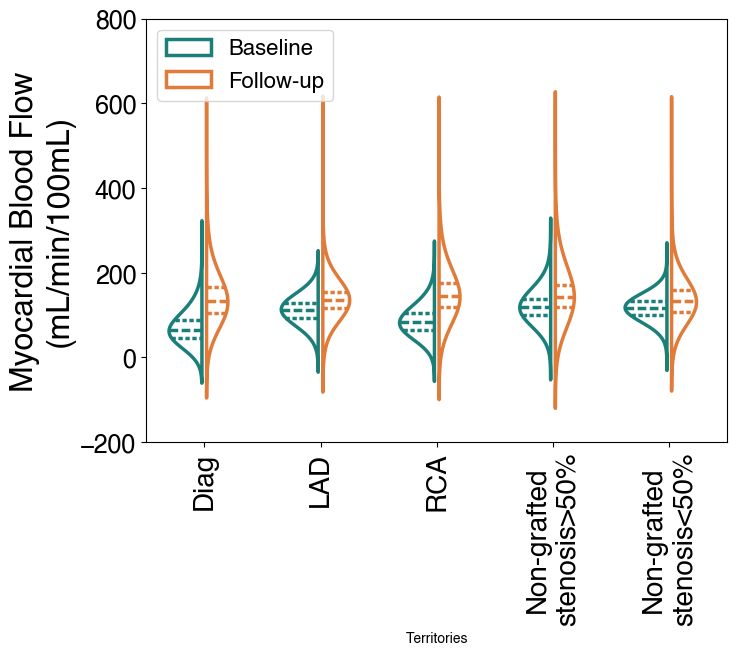

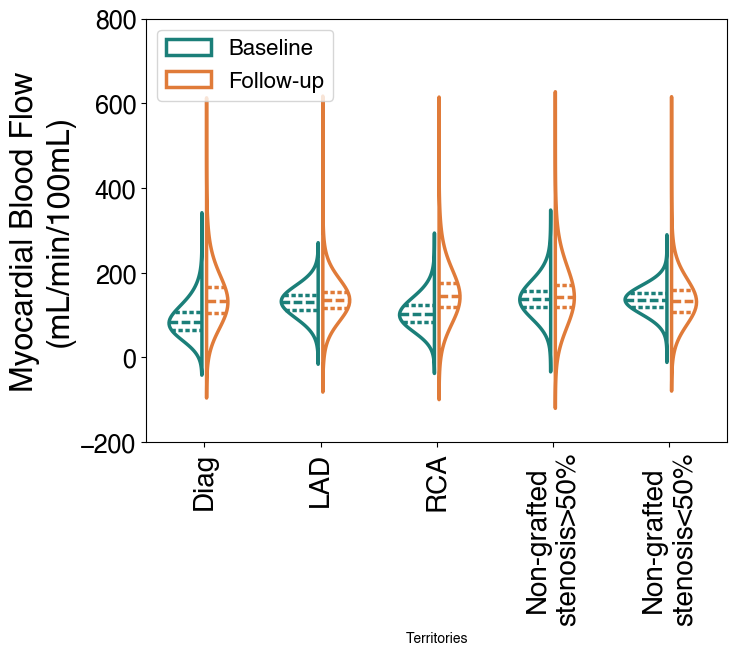

SU04


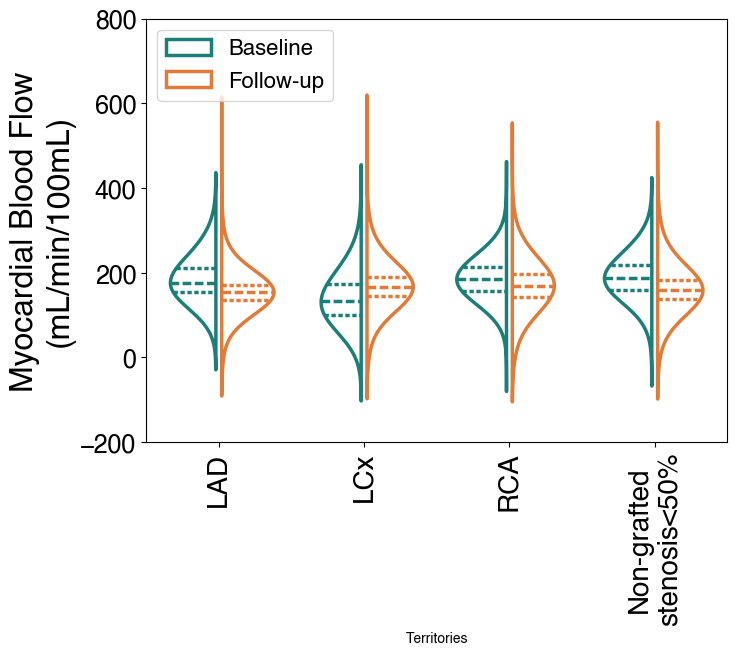

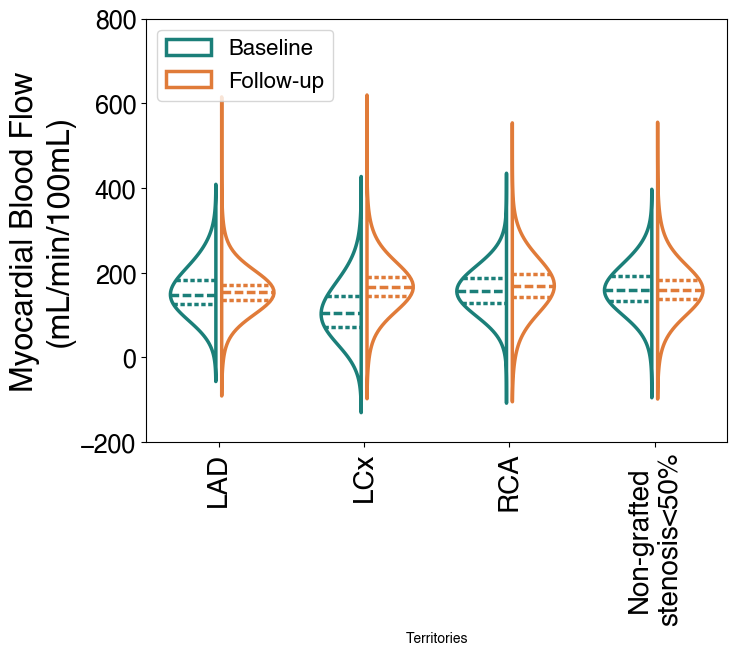

SU06


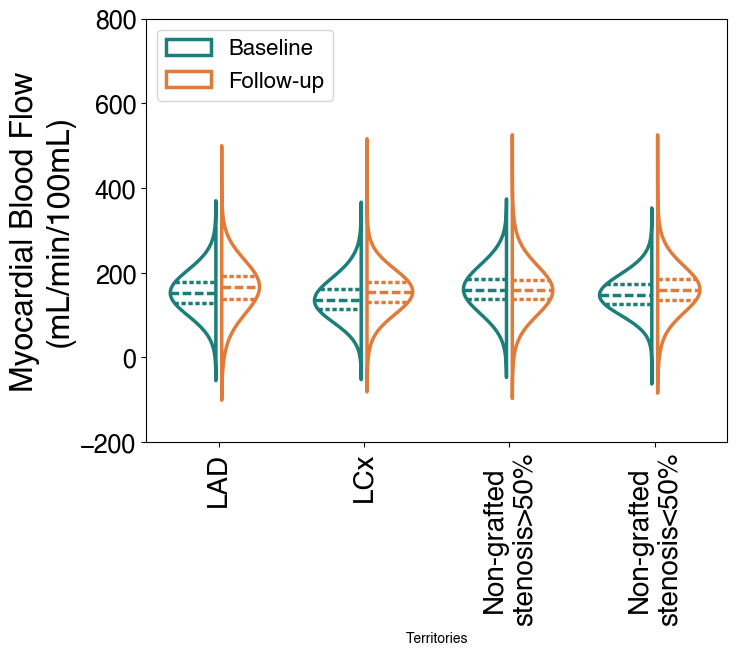

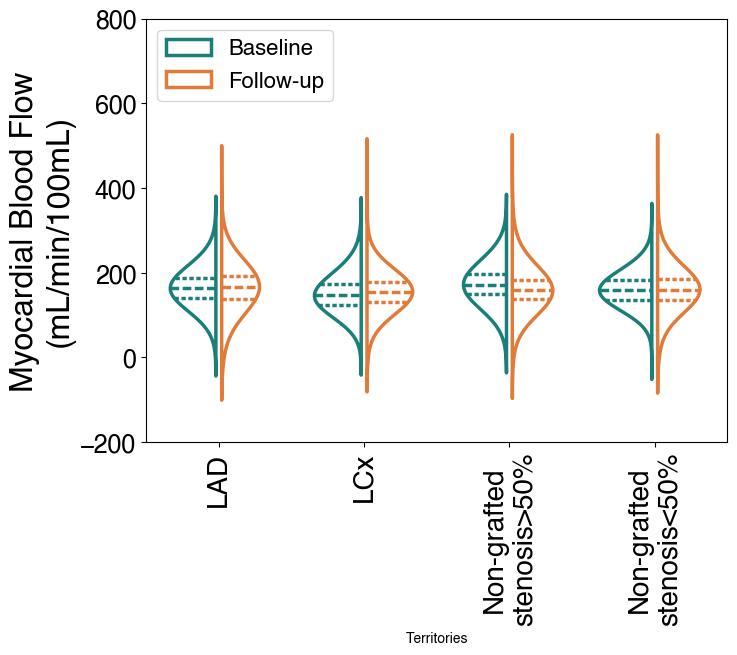

SU07


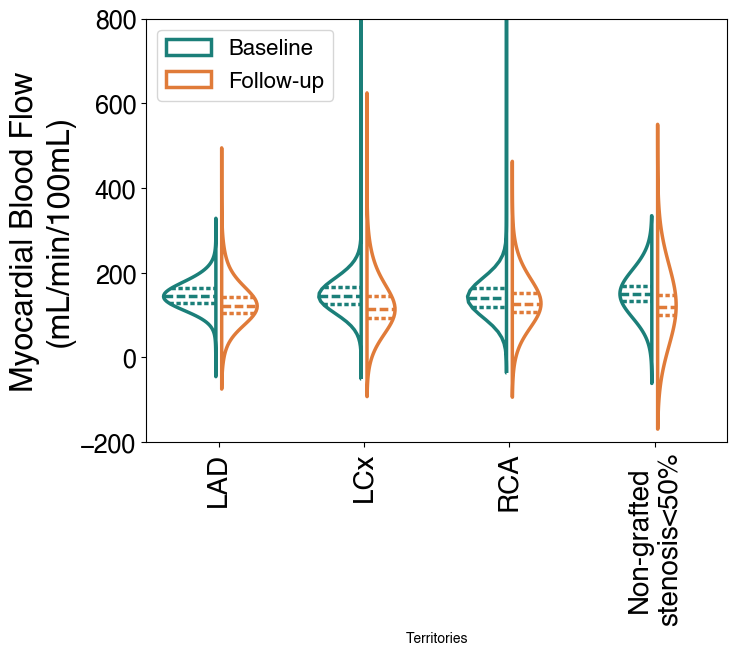

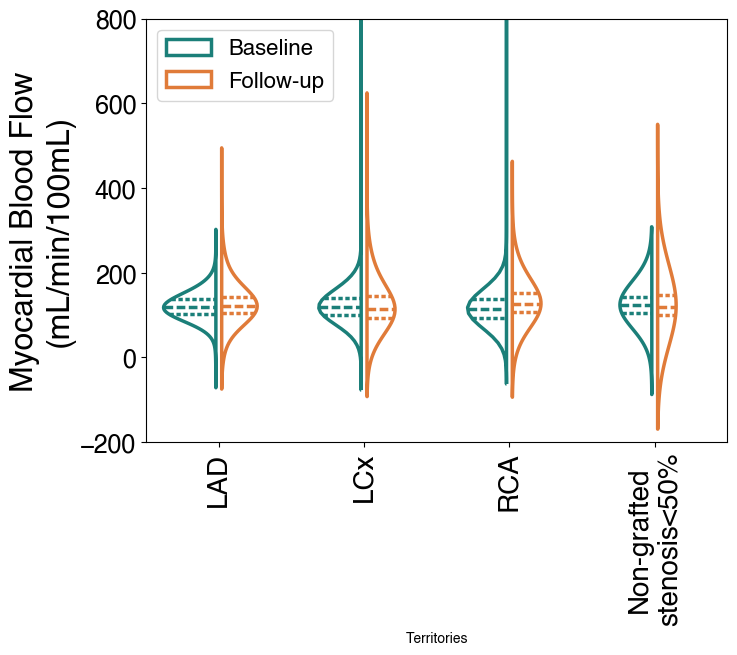

SU10


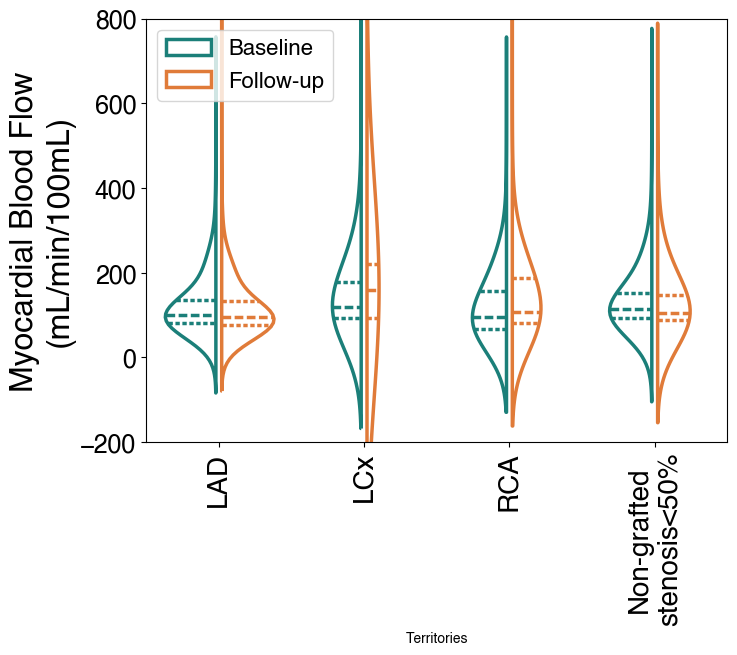

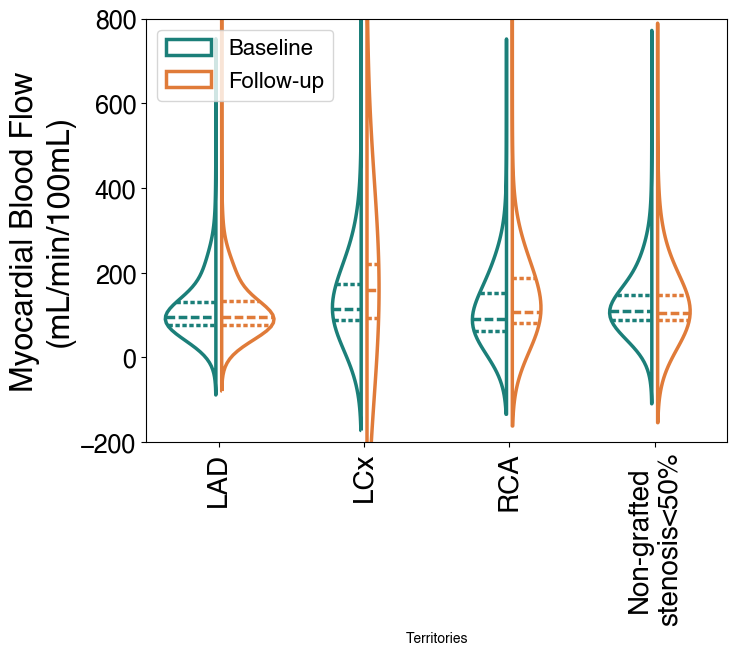

SU11


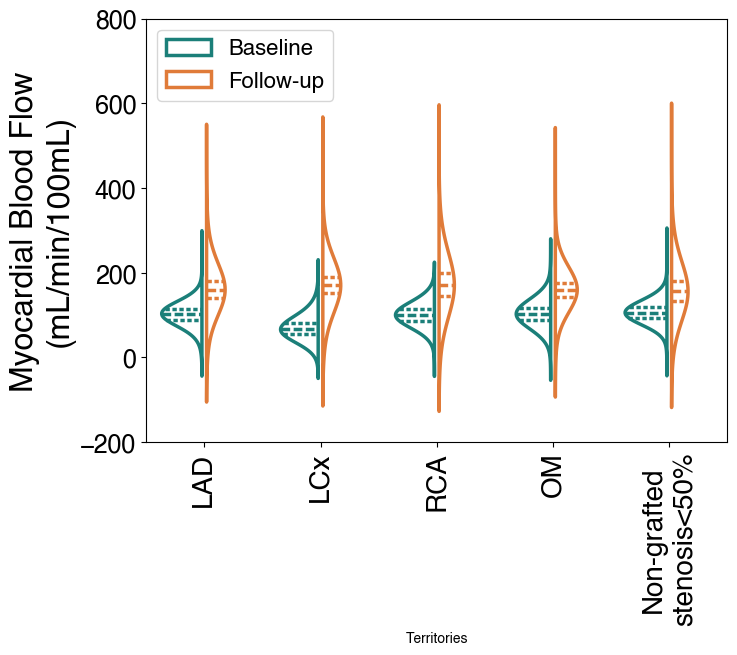

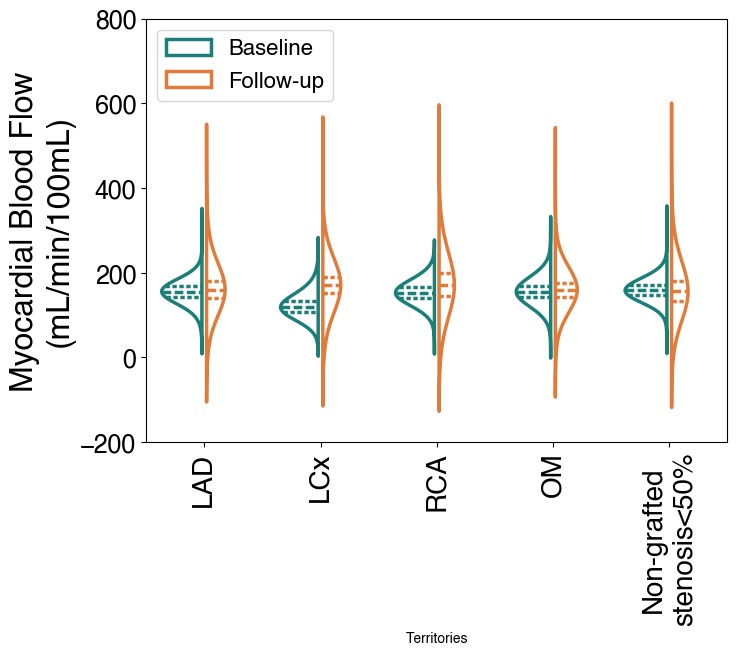

SU13


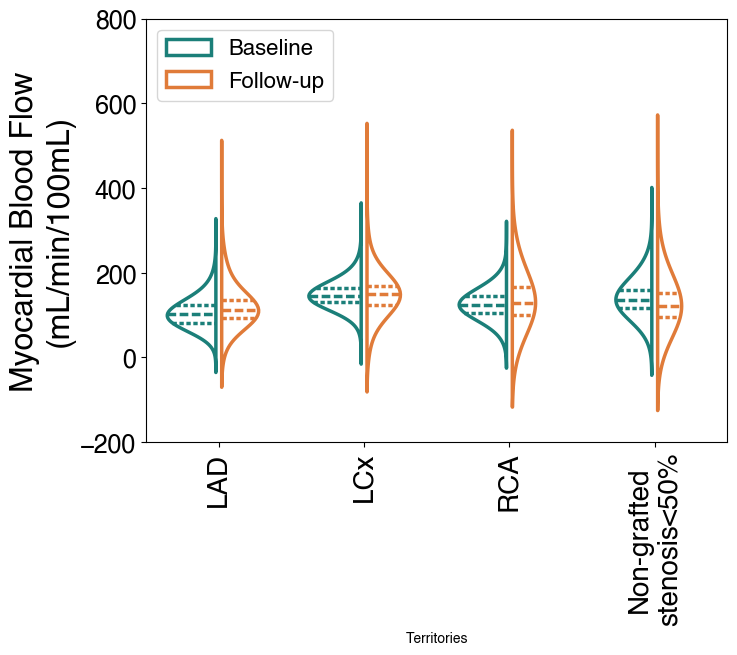

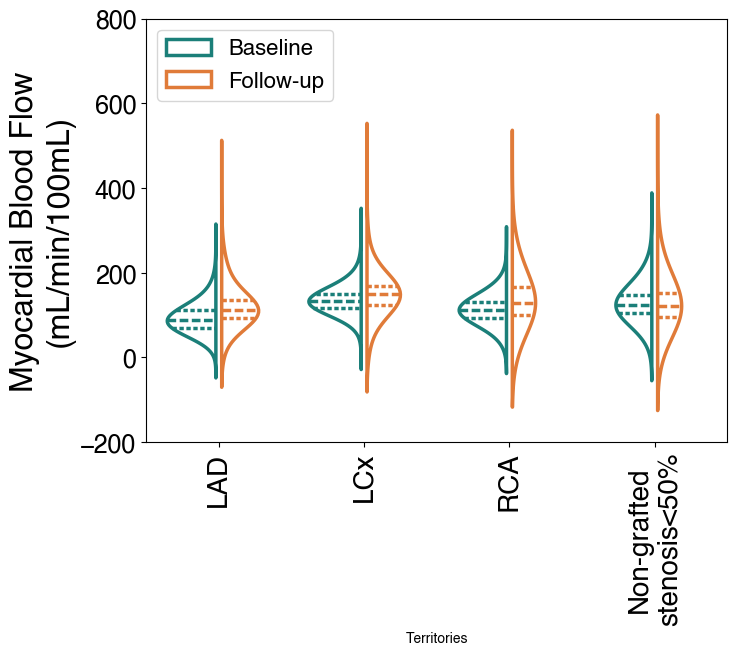

SU14


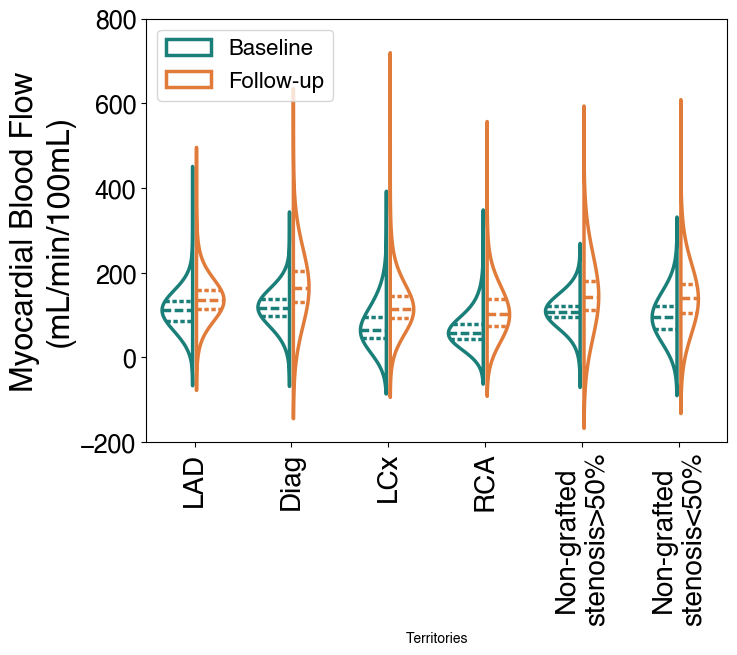

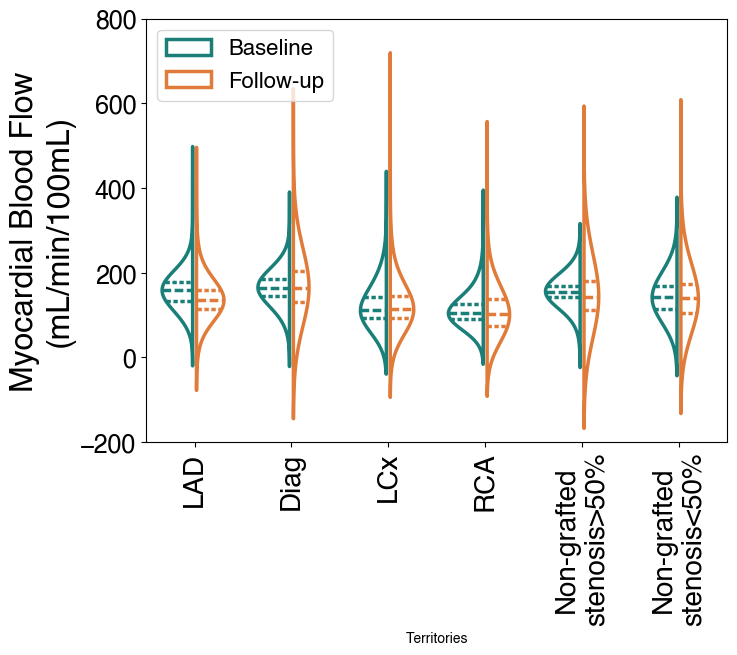

SU16


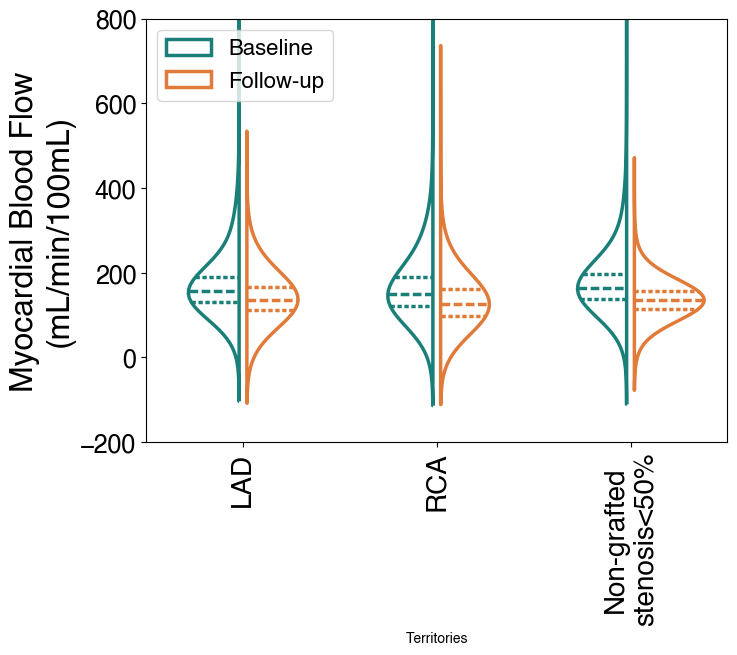

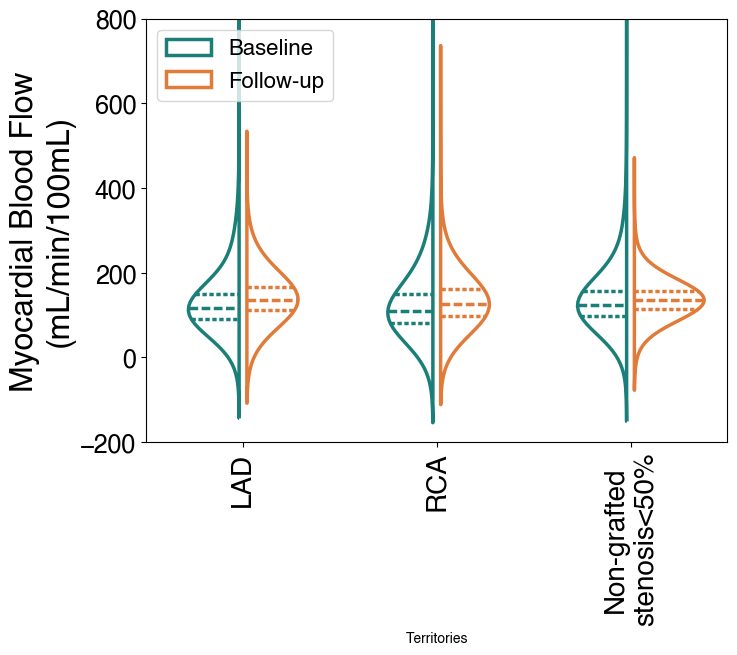

SU21


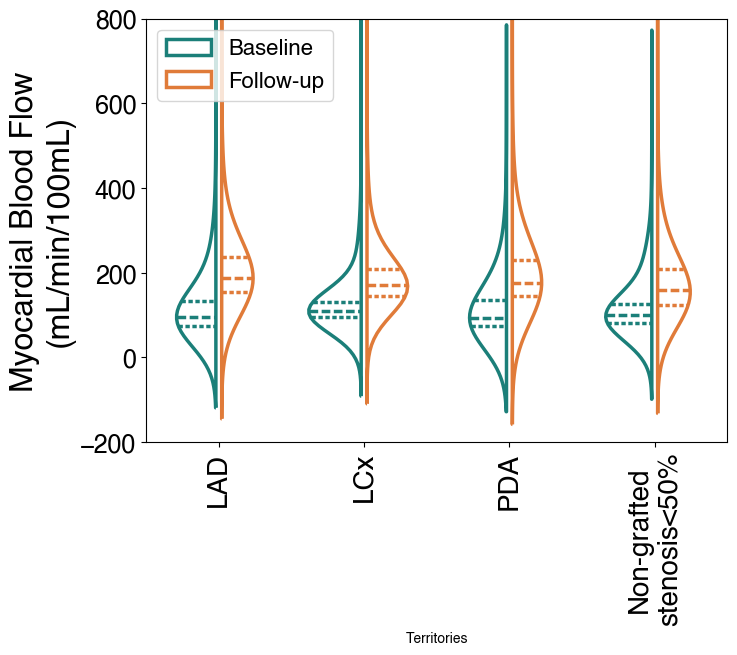

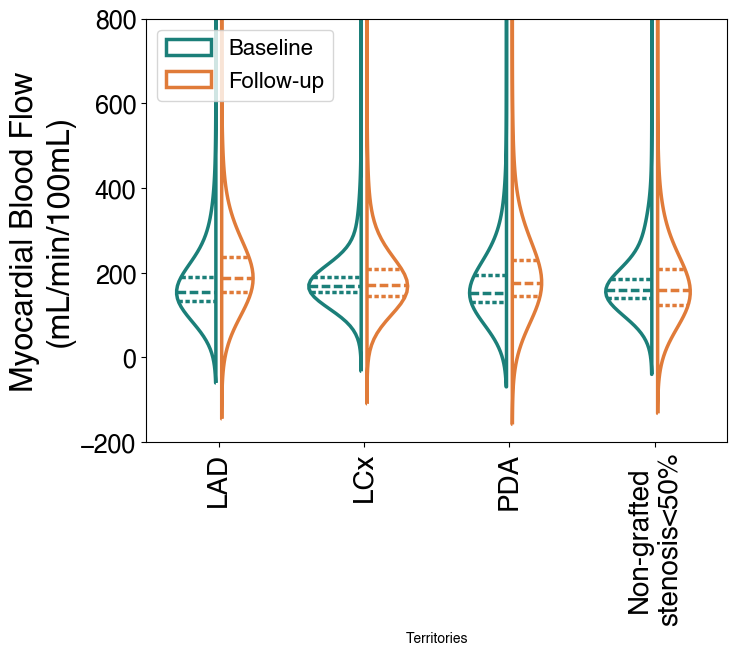

SU23


2026-04-13 19:48:21.090 (  74.935s) [         15C850F]RuntimeDeviceInformatio:237   WARN| Initializing 'RuntimeDeviceConfigurations' with uninitialized configOptions. Did you call viskores::cont::Initialize?


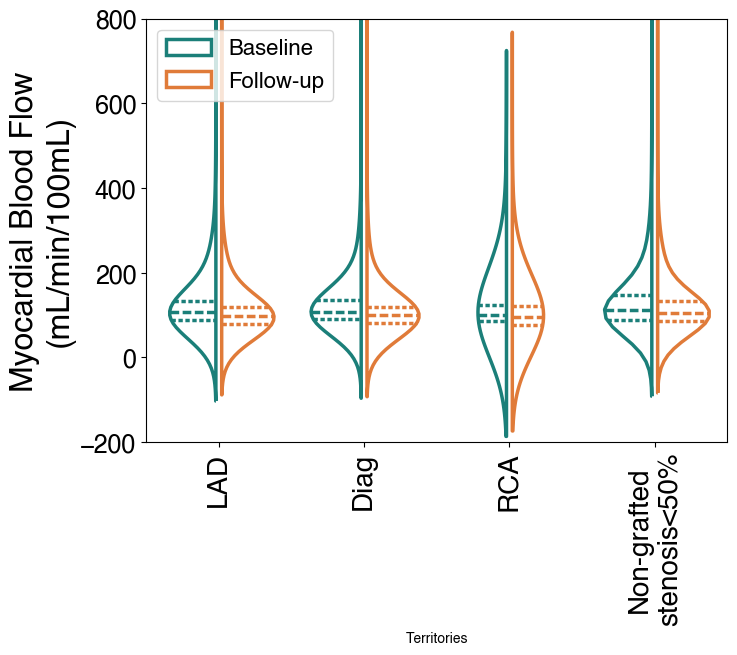

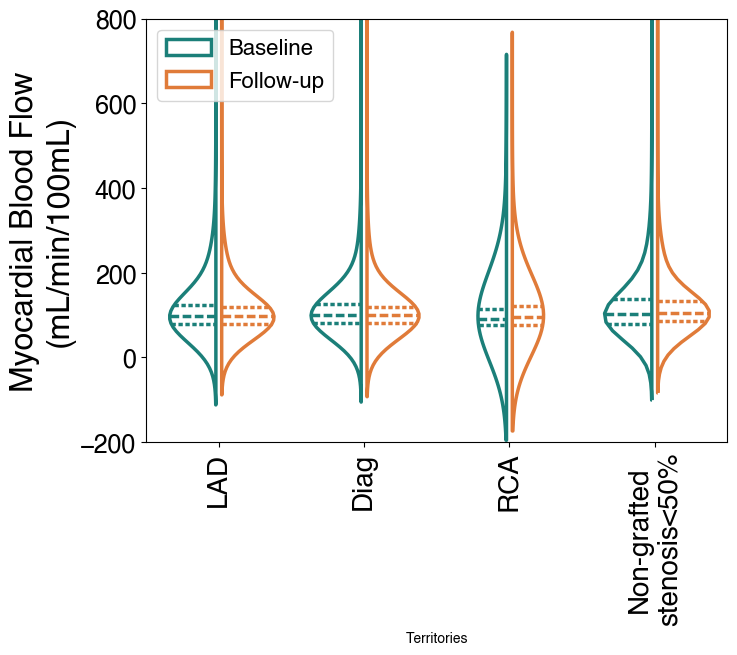

SU24


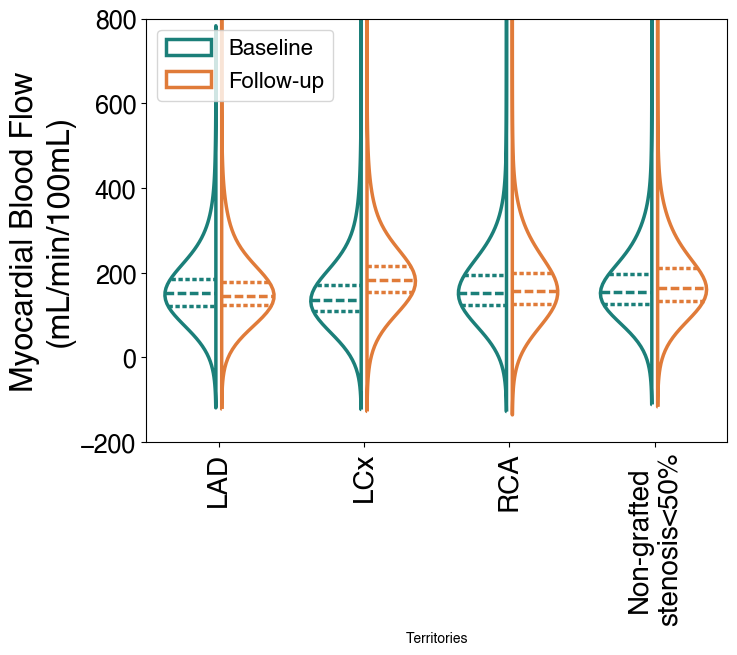

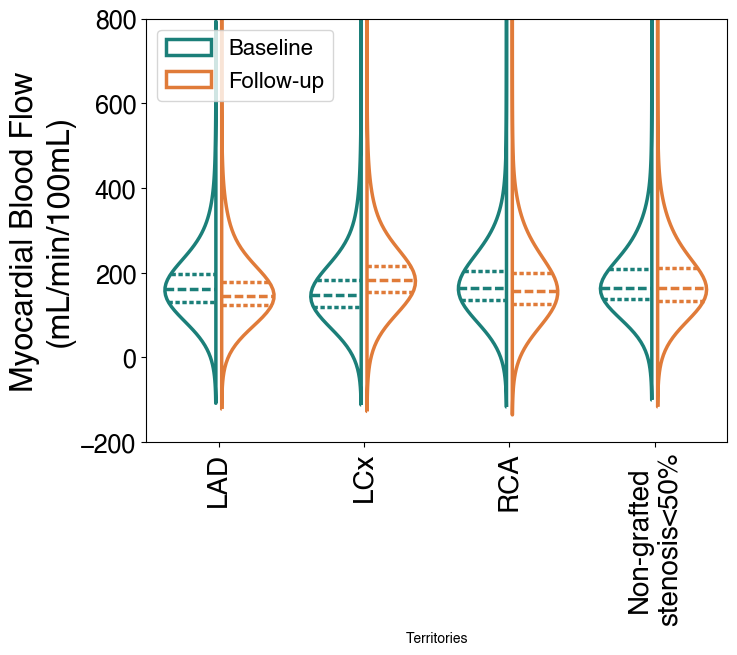

SU25


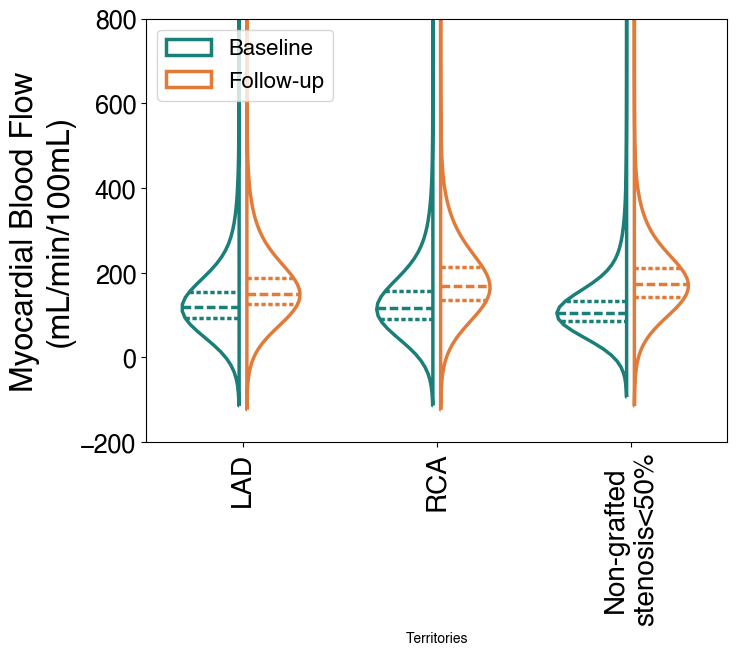

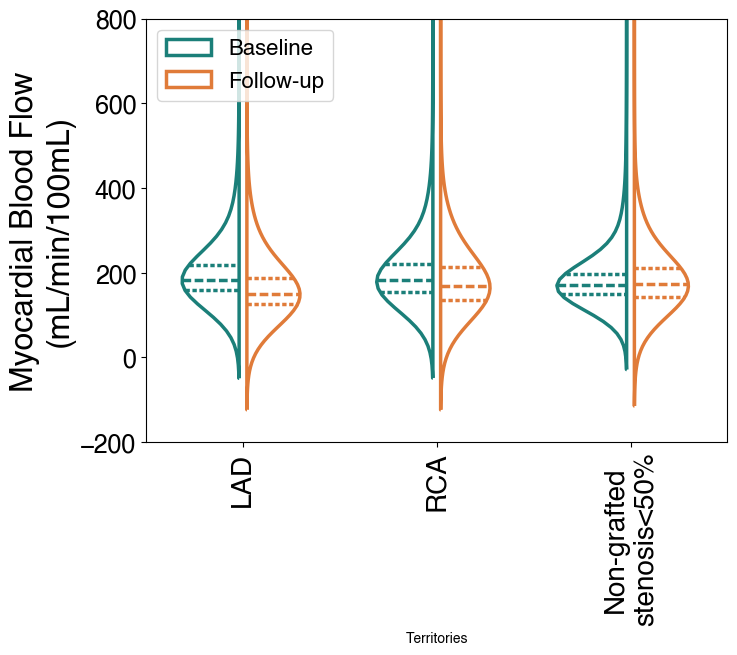

SU26


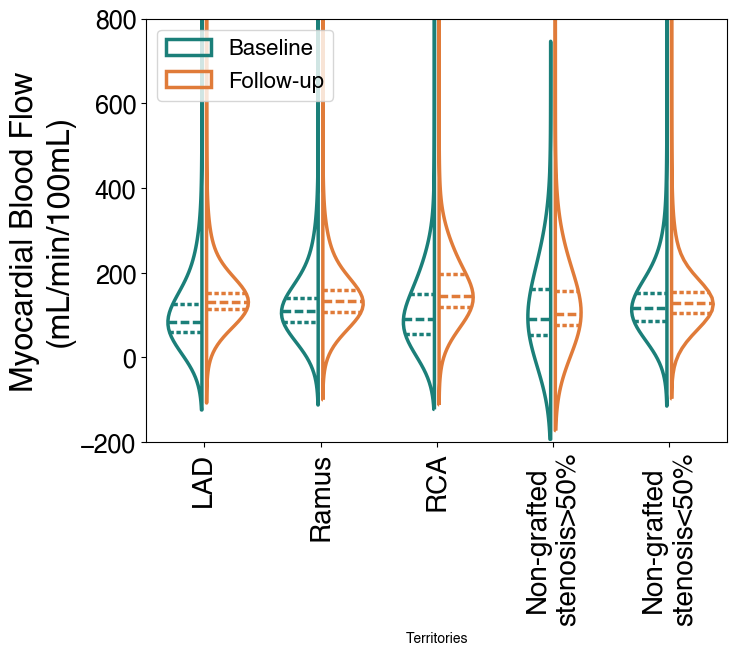

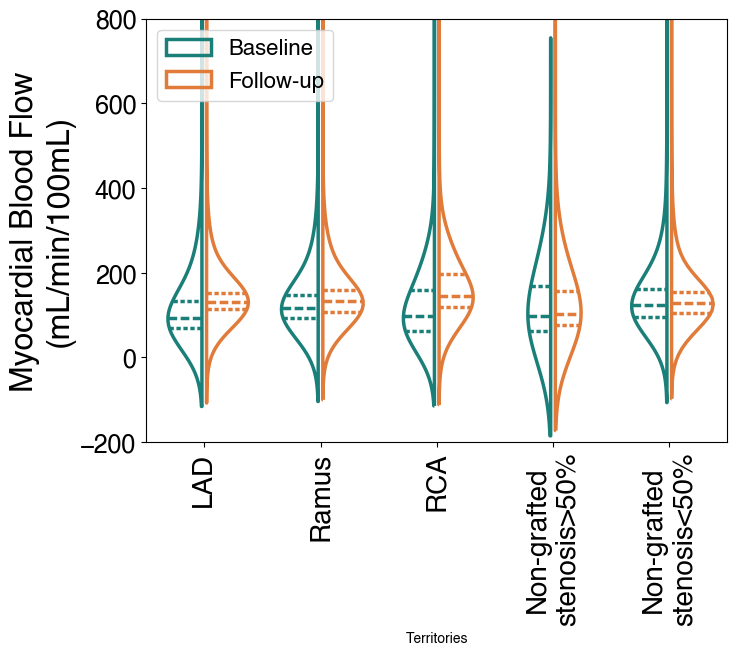

SU27


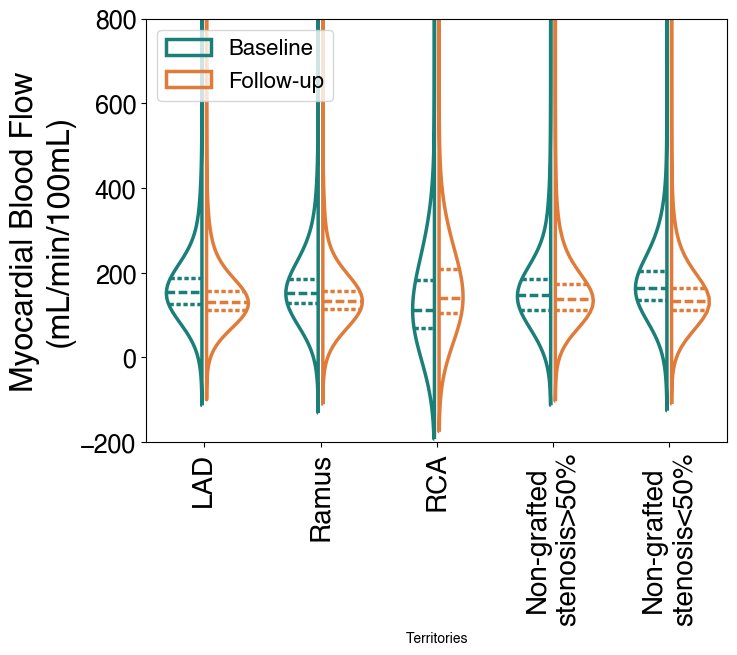

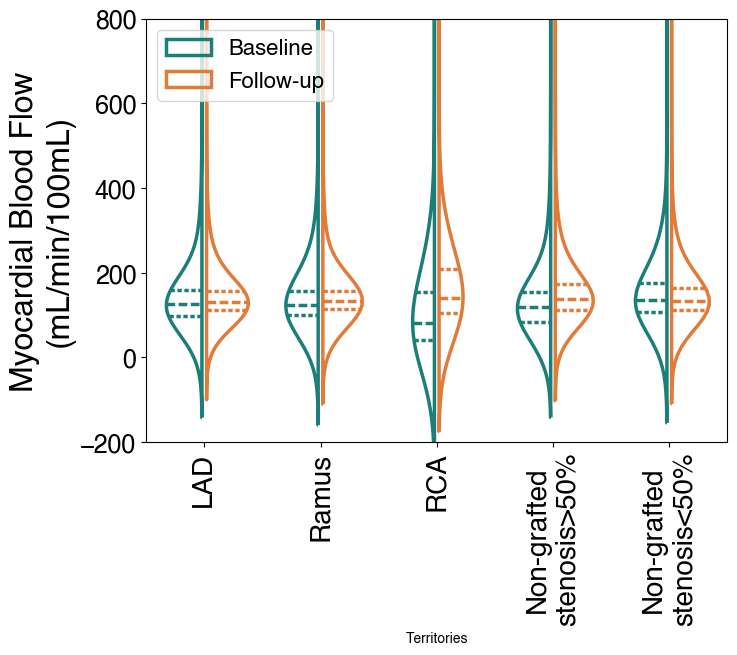

SU28


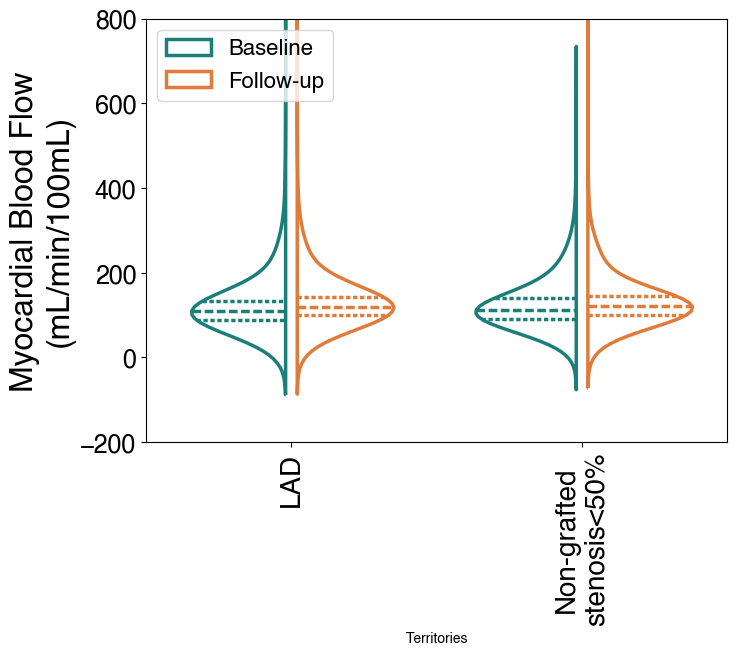

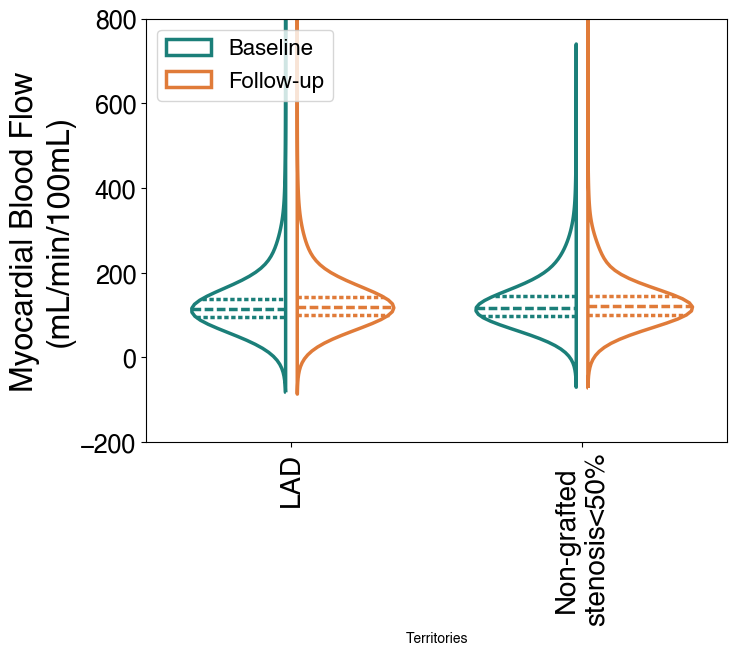

SU30


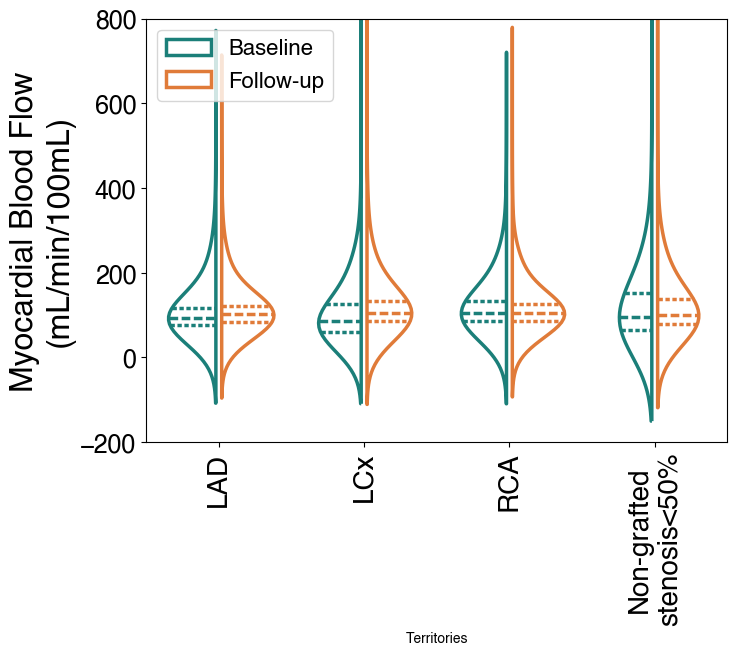

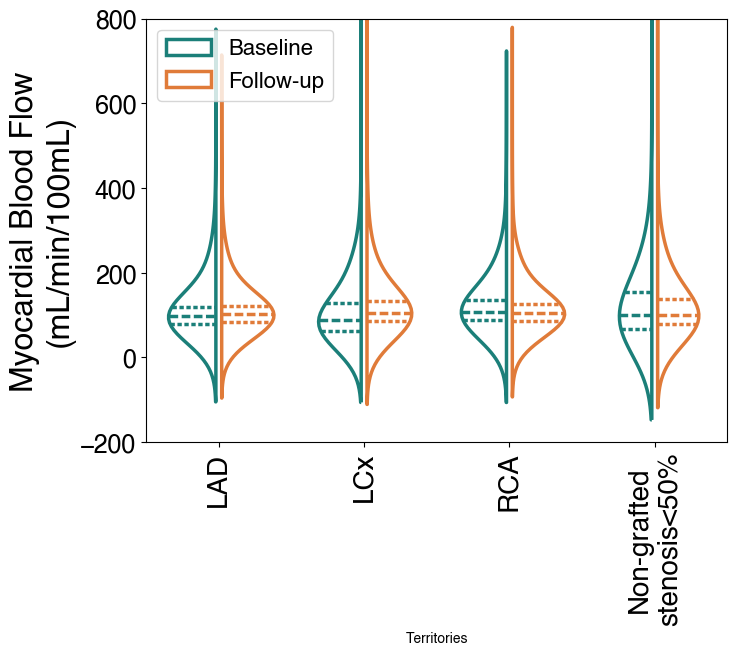

SU33


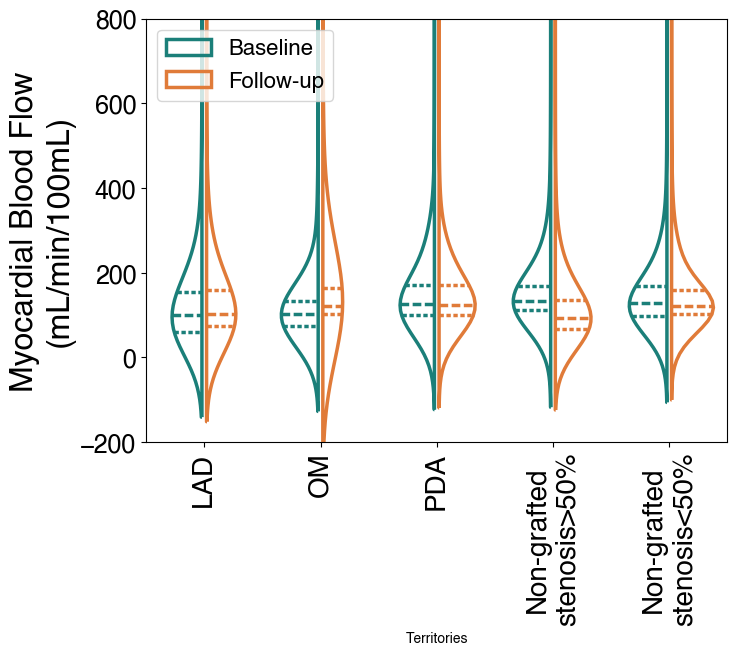

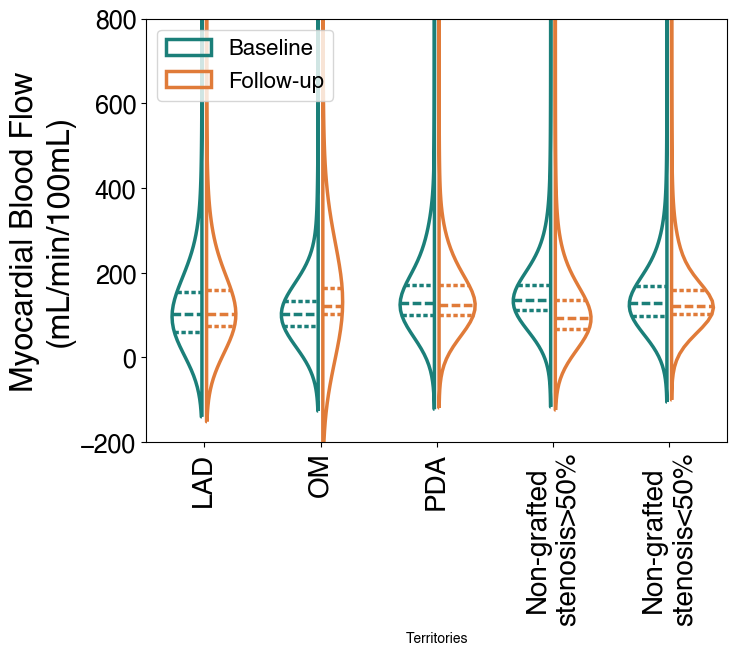

SU34


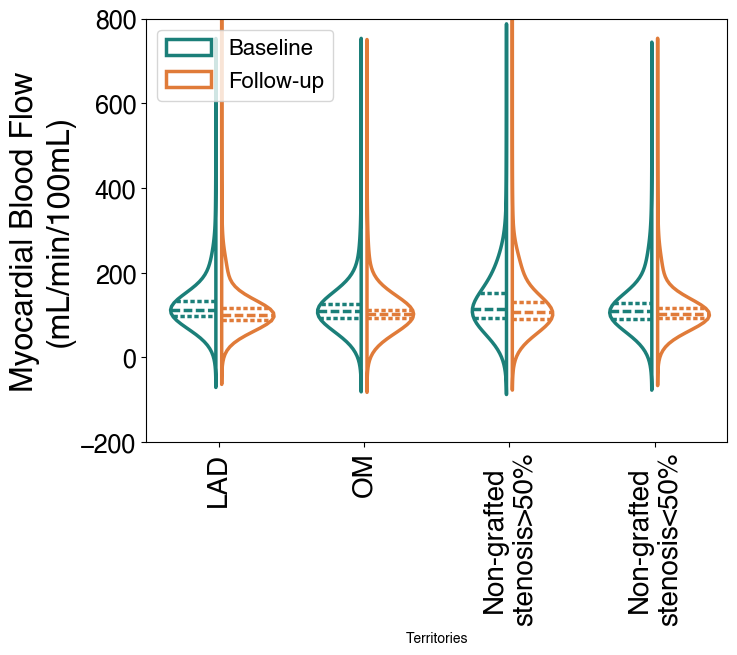

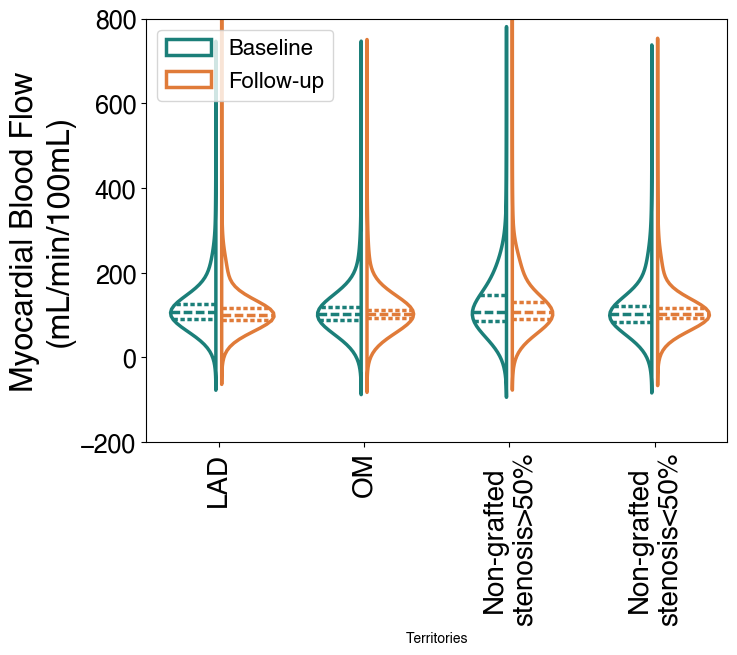

VA02


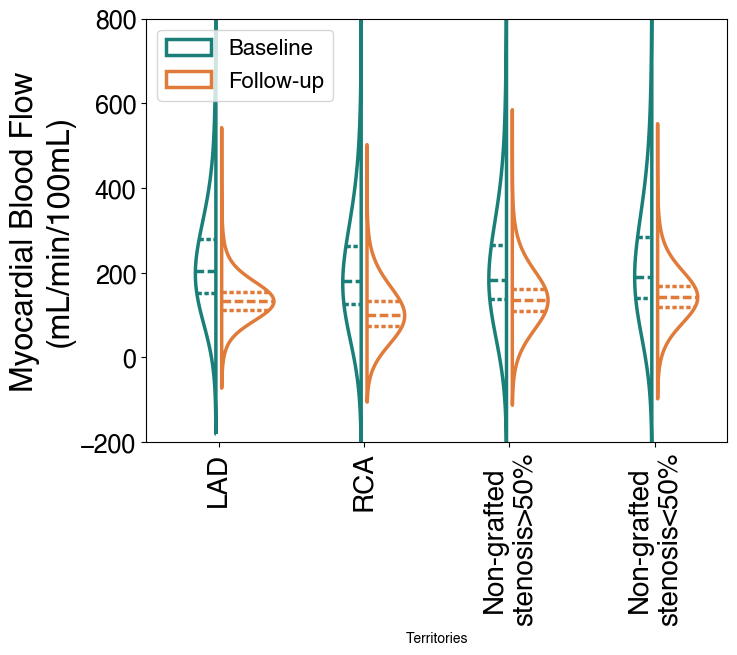

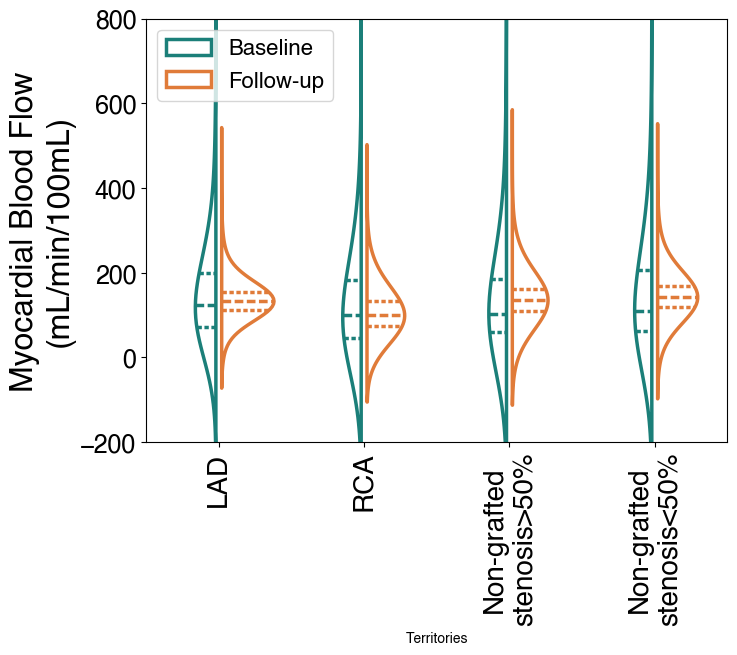

VA04


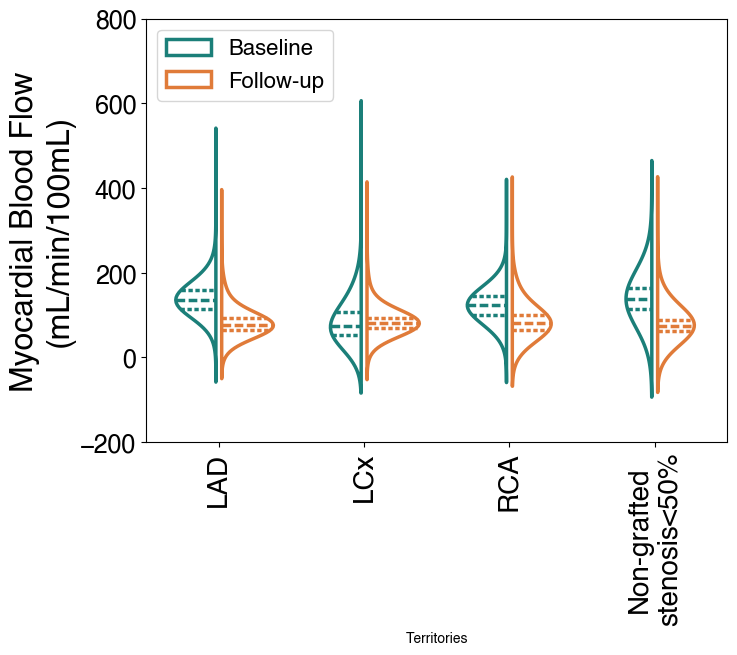

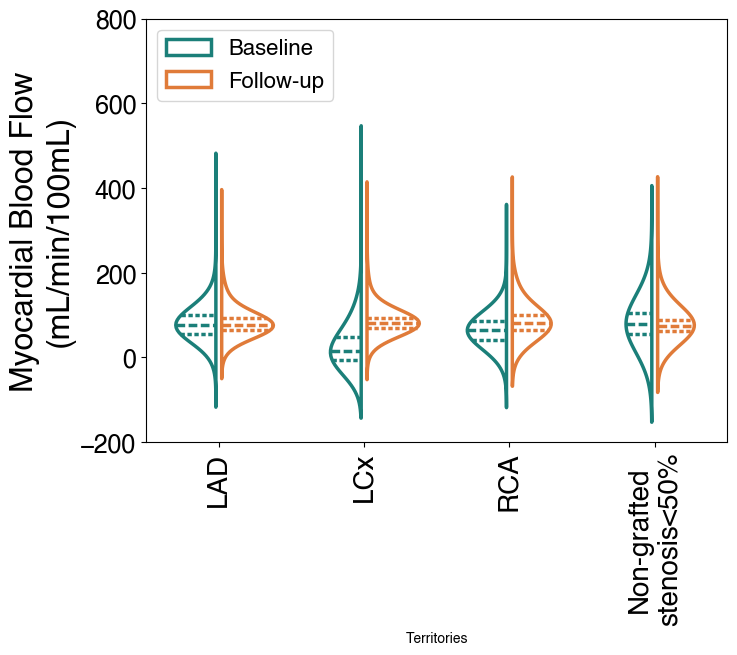

VA06


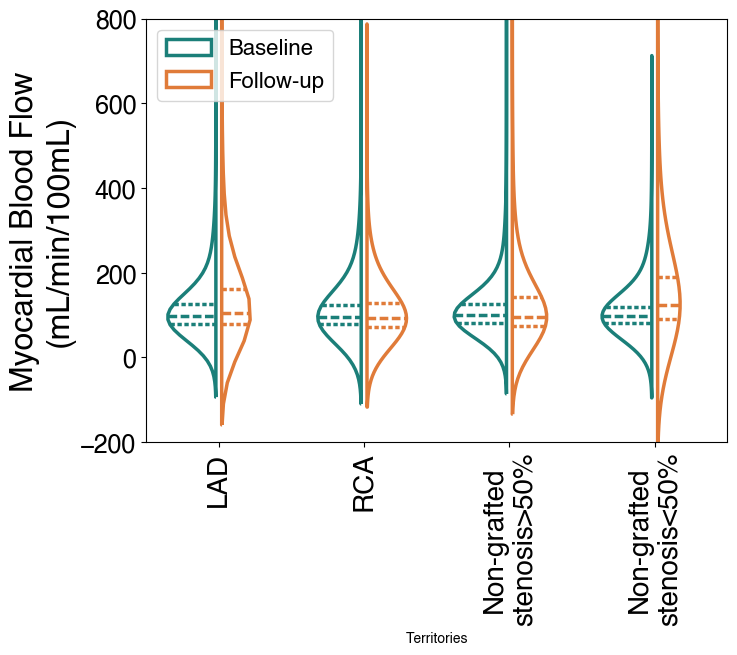

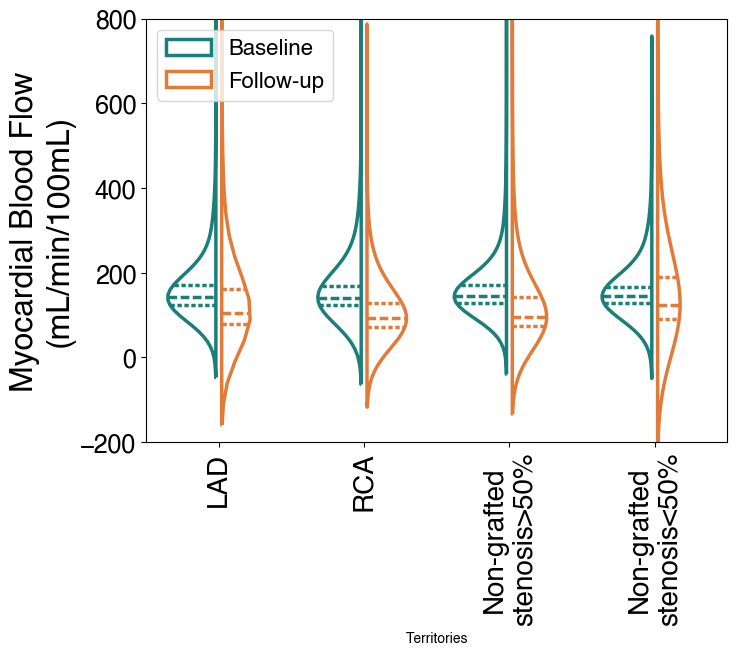

VA08


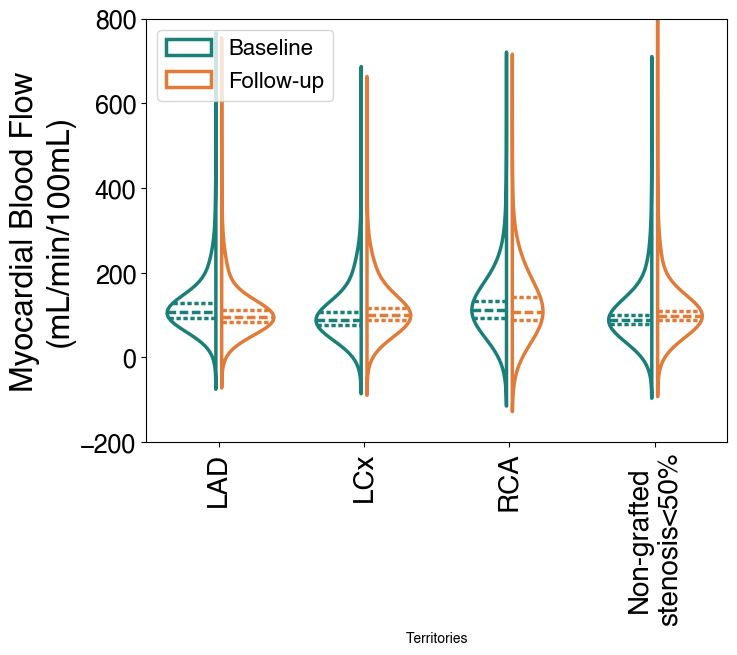

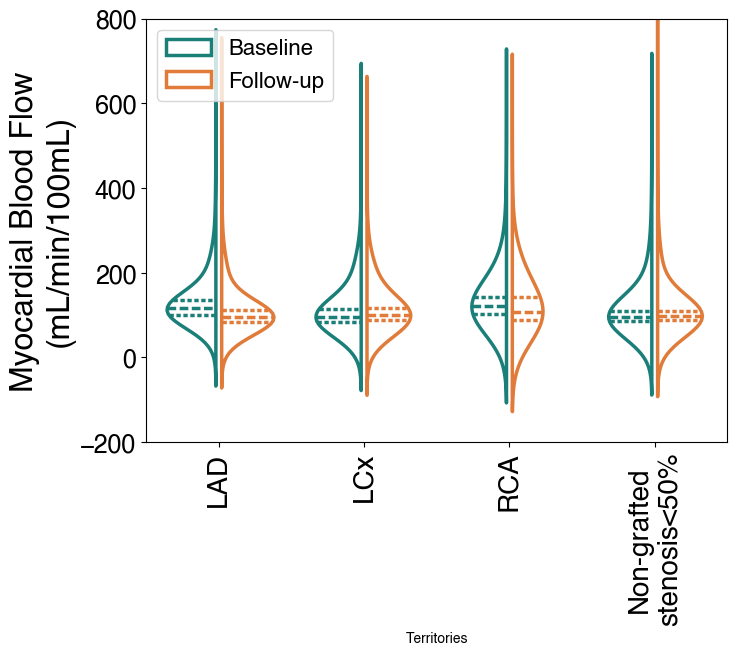

VA10


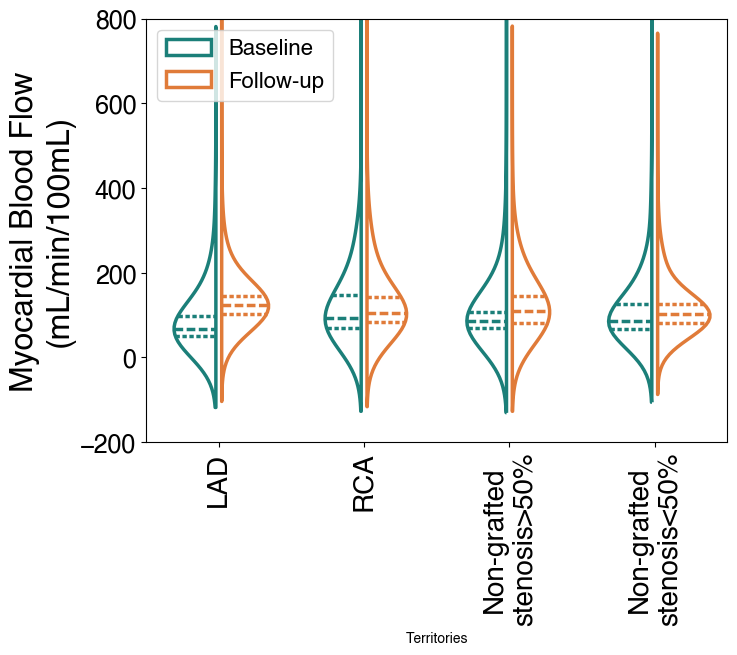

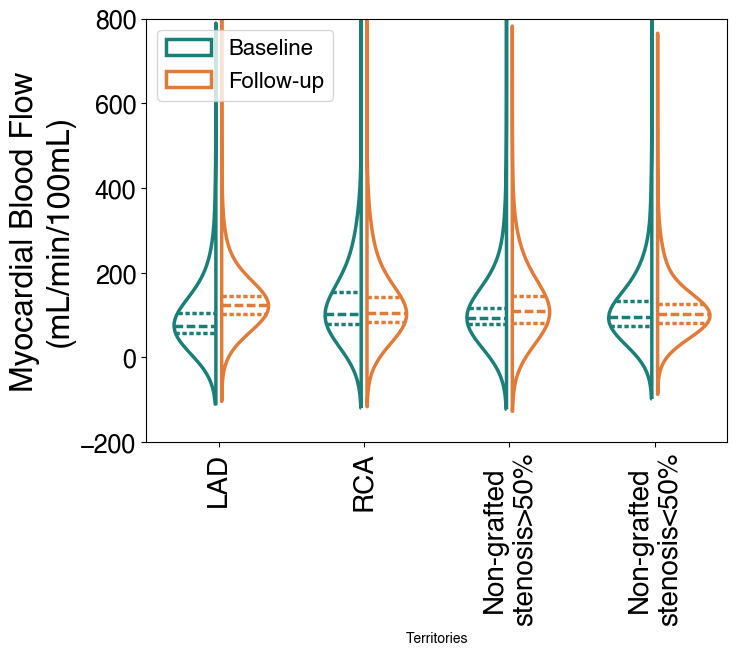

VA13


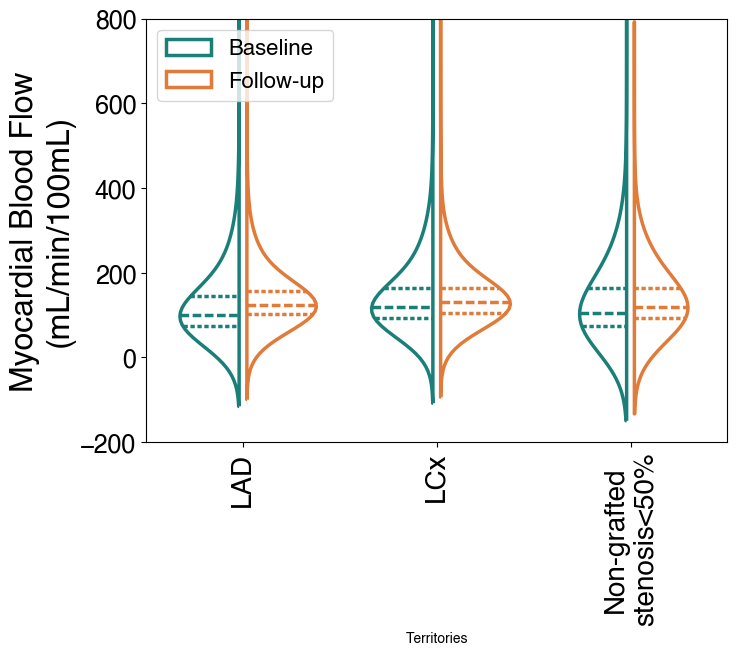

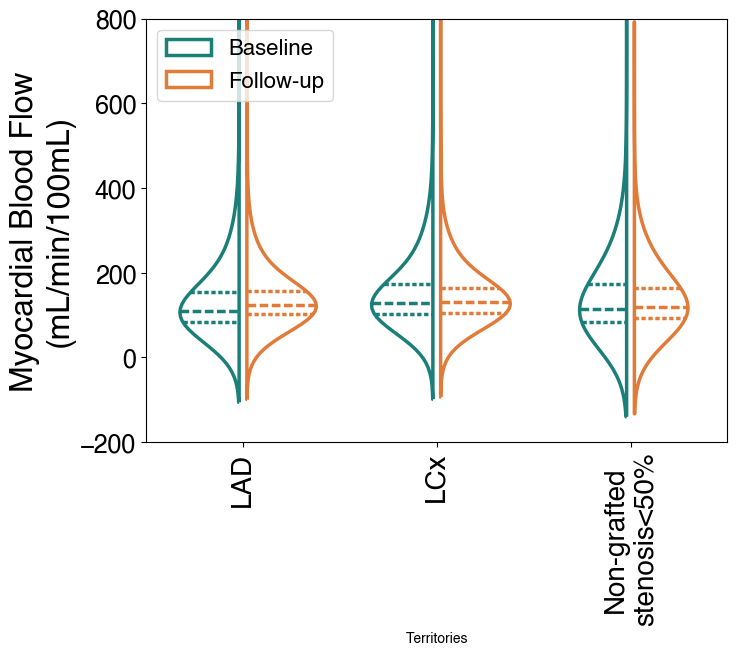

VA14


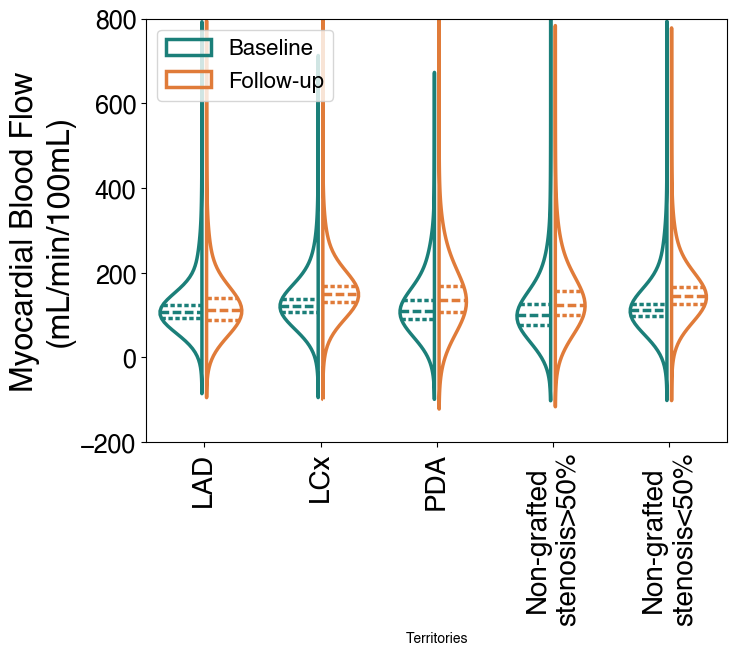

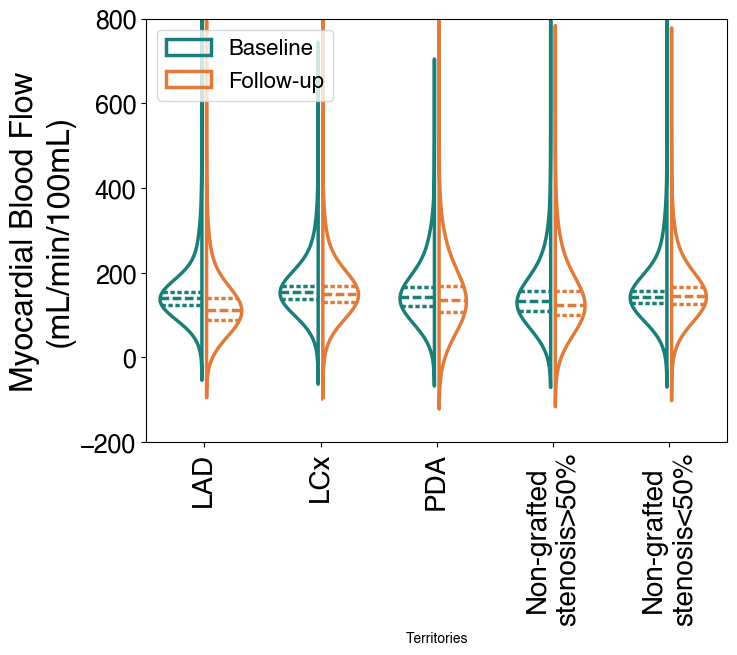

VA16


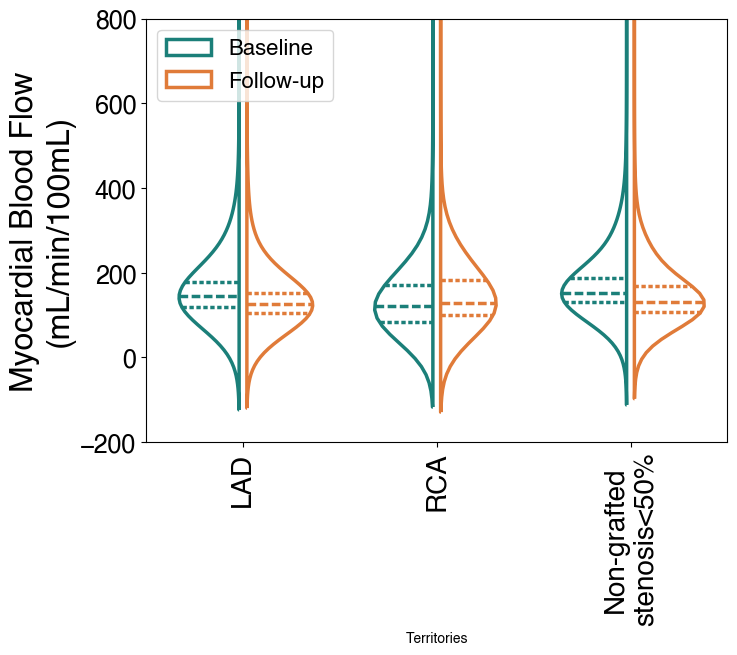

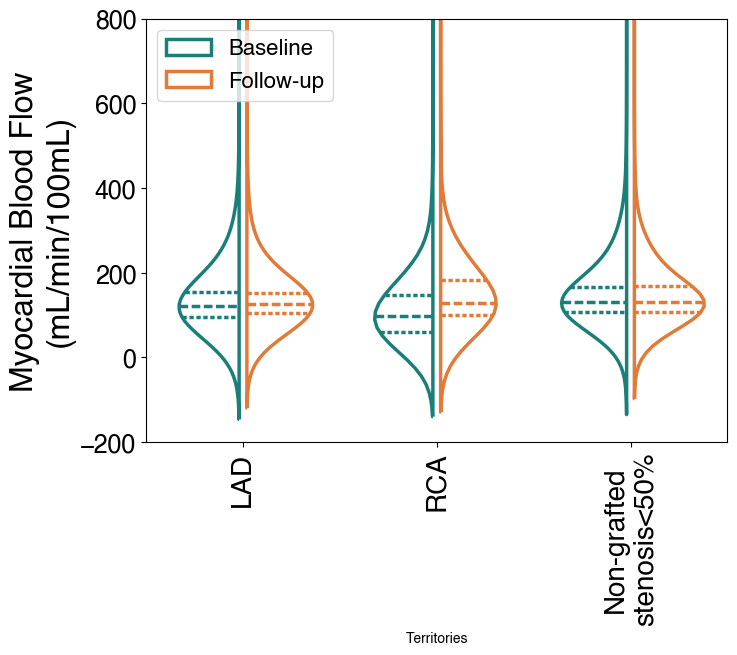

VA20


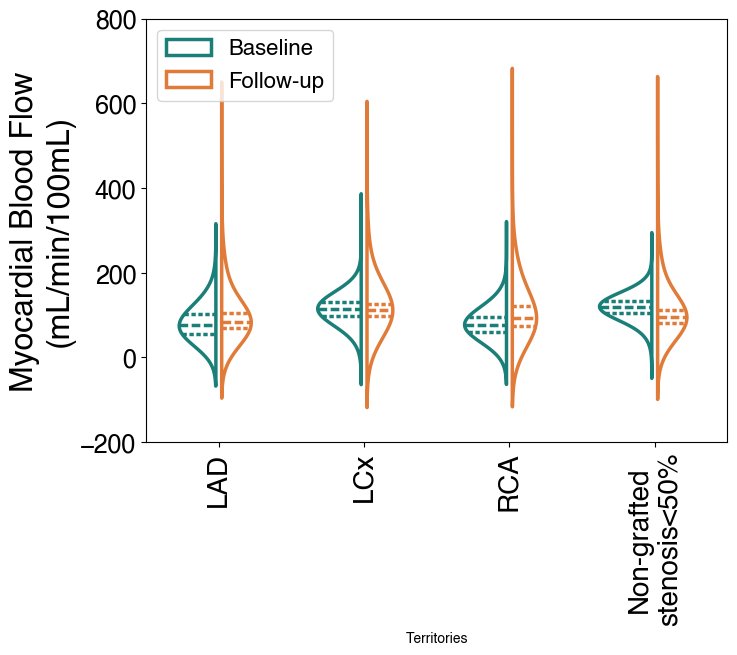

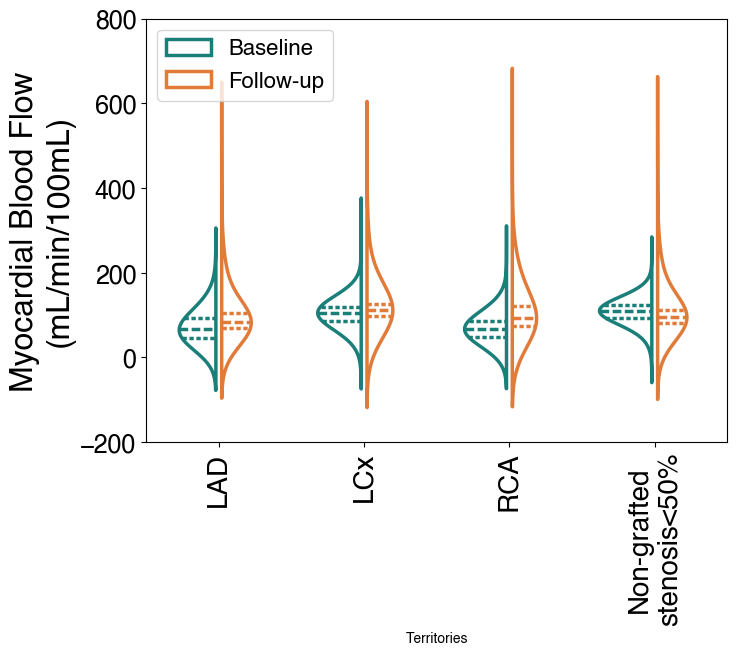

In [7]:
for patient_id in patient_ids:
    print(patient_id)
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "zscore"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
    AbsMBFData_A, IndexMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B, IndexMBFData_B = CollectMBFData(MBF_B, MBF_Labels)
    data = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
    dataMapped = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)
    MBF_A_mapped = Map3DVolume(mean_A, mean_B, std_A, std_B, MBF_A)
    WriteVTUFile(os.path.join(opath,f"{patient_id}A_MBF_Mapped.vtu"), MBF_A_mapped)
    WriteVTUFile(os.path.join(opath,f"{patient_id}B_MBF_Mapped.vtu"), MBF_B)
    #data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['A']*len(array_A) + ['B']*len(array_B)})
    #data = pd.concat([data, data_], ignore_index=True)
    # Mapping
    #data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['A']*len(array_A) + ['B']*len(array_B)})
    #dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    for i, t in enumerate(tags):
        array_A = AbsMBFData_A[t]
        array_B = AbsMBFData_B[t]
        data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        data = pd.concat([data, data_], ignore_index=True)
        # Mapping
        data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_A = AbsMBFData_A[t]
        array_B = AbsMBFData_B[t]
        data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        data = pd.concat([data, data_], ignore_index=True)
        # Mapping
        data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
    data = pd.concat([data, data_], ignore_index=True)
    # Mapping
    data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
    dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    
    
    #BoxPlot(data)
    ViolinPlot(data)
    #print("--- Mapping Results:")
    ViolinPlot(dataMapped)


# Aggregating The Results

In [8]:
# Cases that didn't reach hyperaemia
Removed_Cases = ["SU25", "VA04"]

In [9]:
dataMapped = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])
    graft_stenosis = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft-stenosis'])
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
    AbsMBFData_A, IndexMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B, IndexMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)

    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_A_ = AbsMBFData_A[t]
    mbf_median_non_grafted = np.median(MapNongrafted(mean_A, mean_B, std_A, std_B, np.concatenate([array_A, array_A_])))


    MBF_A_array = GetMBFArray(MBF_A)
    ref = np.percentile(MBF_A_array, 75)

    threshold1 = 0.9 * mbf_median_non_grafted  # 10% drop
    threshold2 = 0.8 * mbf_median_non_grafted  # 20% drop
    threshold3 = 0.7 * mbf_median_non_grafted  # 30% drop

    for i, t in enumerate(tags):
        AbsMBFData_A_mapped = MapNongrafted(mean_A, mean_B, std_A, std_B, AbsMBFData_A[t])
        mbf_median = np.median(AbsMBFData_A_mapped)
        if mbf_median > threshold1:
            is_ischemic = False
            ischemia_grade = 0
        elif threshold2 < mbf_median <= threshold1:
            is_ischemic = True
            ischemia_grade = 1
        elif threshold3 < mbf_median <= threshold2:
            is_ischemic = True
            ischemia_grade = 2
        else:
            is_ischemic = True
            ischemia_grade = 3

        data_ = {"patient_id": patient_id, "tag": t, "graft_type": grafts[i], "is_ischemic": is_ischemic, "ischemic_grade":ischemia_grade, "graft_stenosis": graft_stenosis[i], "absMBF_A": AbsMBFData_A_mapped, "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        AbsMBFData_A_mapped = MapNongrafted(mean_A, mean_B, std_A, std_B, AbsMBFData_A[t])
        data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A_mapped, "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
        dataMapped.append(data_)
    t = "Non-grafted\nstenosis<50%"
    AbsMBFData_A_mapped = MapNongrafted(mean_A, mean_B, std_A, std_B, AbsMBFData_A[t])
    data_ = {"patient_id": patient_id, "tag": t, "graft_type": None, "is_ischemic": False, "ischemic_grade":0, "graft_stenosis": 0, "absMBF_A": AbsMBFData_A_mapped, "absMBF_B": AbsMBFData_B[t], "rawMBF_A": AbsMBFData_A[t]}
    dataMapped.append(data_)


In [10]:
df = pd.DataFrame(dataMapped)
df

,patient_id,tag,graft_type,is_ischemic,ischemic_grade,graft_stenosis,absMBF_A,absMBF_B,rawMBF_A
0,SU03,Diag,Radial,True,3,0,"[57.862900716365246, 58.862900716365246, 54.86...","[162.0, 155.0, 187.0, 179.0, 168.0, 162.0, 159...","[39.0, 40.0, 36.0, 38.0, 39.0, 40.0, 37.0, 35...."
1,SU03,LAD,LIMA,False,0,0,"[133.86290071636523, 134.86290071636523, 134.8...","[158.0, 158.0, 154.0, 149.0, 143.0, 148.0, 151...","[115.0, 116.0, 116.0, 117.0, 116.0, 114.0, 117..."
2,SU03,RCA,SVG,True,2,0,"[129.86290071636523, 125.86290071636525, 120.8...","[154.0, 159.0, 175.0, 91.0, 93.0, 96.0, 229.0,...","[111.0, 107.0, 102.0, 78.0, 95.0, 78.0, 88.0, ..."
3,SU03,Non-grafted\nstenosis>50%,NaN,False,0,0,"[74.86290071636525, 81.86290071636525, 88.8629...","[74.0, 74.0, 75.0, 79.0, 86.0, 94.0, 103.0, 11...","[56.0, 63.0, 70.0, 79.0, 88.0, 96.0, 105.0, 11..."
4,SU03,Non-grafted\nstenosis<50%,NaN,False,0,0,"[129.86290071636523, 129.86290071636523, 127.8...","[111.0, 123.0, 139.0, 126.0, 107.0, 106.0, 110...","[111.0, 111.0, 109.0, 109.0, 109.0, 109.0, 109..."
...,...,...,...,...,...,...,...,...,...
102,VA16,Non-grafted\nstenosis<50%,NaN,False,0,0,"[32.326858762198896, 5.326858762198896, 16.326...","[201.0, 204.0, 288.0, 285.0, 128.0, 134.0, 386...","[55.0, 28.0, 39.0, 15.0, 52.0, 75.0, 38.0, 58...."
103,VA20,LAD,LIMA,True,3,0,"[22.9264521322403, 4.9264521322403, 7.92645213...","[221.0, 145.0, 185.0, 129.0, 33.0, 80.0, 9.0, ...","[33.0, 15.0, 18.0, 30.0, 27.0, 15.0, 19.0, 30...."
104,VA20,LCx,SVG,False,0,0,"[68.9264521322403, 58.9264521322403, 51.926452...","[42.0, 41.0, 42.0, 45.0, 46.0, 34.0, 29.0, 46....","[79.0, 69.0, 62.0, 59.0, 58.0, 60.0, 62.0, 64...."
105,VA20,RCA,SVG,True,3,0,"[116.9264521322403, 116.9264521322403, 116.926...","[6.0, 8.0, 15.0, 5.0, 90.0, 92.0, 88.0, 88.0, ...","[127.0, 127.0, 127.0, 123.0, 99.0, 94.0, 101.0..."


### Plot based on the presence of ischemia

In [11]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_g = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_grafted_A", q2, q3-q1, average_g, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_grafted_A 117.95032549960712 65.31688087761805 128.03864106207104 62.63000170265896
all_grafted_B 121.0 67.0 133.92522540871403 62.241138084515605


In [12]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("all_not_grafted_A", q2, q3-q1, average_ng, std)

mbf_ischemic_B = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("all_not_grafted_B",q2, q3-q1, average, std)

TerritoryTag Median IQR Mean std
all_not_grafted_A 125.87558362063675 66.76099920718104 136.5832083060746 64.73134789110044
all_not_grafted_B 121.0 63.0 134.99193586295303 63.911882019185335


In [13]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == 'Non-grafted\nstenosis<50%')]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("nosten_not_grafted_A", q2, q3-q1, average_ng, std)

print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[(df['tag'] == "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average_ng = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("sten_not_grafted_A", q2, q3-q1, average_ng, std)

TerritoryTag Median IQR Mean std
nosten_not_grafted_A 125.26173366940696 66.76099920718104 136.62577929614173 63.76908647224625
TerritoryTag Median IQR Mean std
sten_not_grafted_A 127.44485563543066 66.69412519431836 136.4535932754744 67.5766439437685


In [14]:
median_mbf_ng_sten_A = [] #grafted regions
median_mbf_ng_nsten_A = [] # not grafted regions

for _, row in df[(df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_sten_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%')].iterrows():
    median_mbf_ng_nsten_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_sten_A, median_mbf_ng_nsten_A, alternative="two-sided")
print(stat)
print(p_value_)
print(p_value_<0.05)

140.0
0.9337941146708102
False


In [15]:
median_mbf_g_A = [] #grafted regions
median_mbf_ng_A = [] # not grafted regions

for _, row in df[(df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_g_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['tag'] == 'Non-grafted\nstenosis<50%') | (df['tag'] == "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_ng_A, median_mbf_g_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

1540.0
0.0546396493446182
False


In [16]:
median_mbf_sg_A = [] #with stenosis grafted
median_mbf_nsg_A = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_A.append(np.median(row['absMBF_A']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_A.append(np.median(row['absMBF_A']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_A, median_mbf_sg_A, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

1004.0
3.2332546357465404e-08
True


In [17]:
median_mbf_sg_B = [] #with stenosis grafted
median_mbf_nsg_B = [] #not stenosis grafted

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_sg_B.append(np.median(row['absMBF_B']))
for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nsg_B.append(np.median(row['absMBF_B']))

stat, p_value_ = mannwhitneyu(median_mbf_nsg_B, median_mbf_sg_B, alternative="greater")
print(stat)
print(p_value_)
print(p_value_<0.05)

697.0
0.05020906922308365
False


In [18]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic_A = np.concatenate(df[df['is_ischemic'] == True]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_A, [25, 50, 75])
average = np.mean(mbf_ischemic_A)
std = np.std(mbf_ischemic_A)
print("ischemic_grafted_A", q2, q3-q1, average, std)

mbf_ischemic_B = np.concatenate(df[df['is_ischemic'] == True]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic_B, [25, 50, 75])
average = np.mean(mbf_ischemic_B)
std = np.std(mbf_ischemic_B)
print("ischemic_grafted_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)

mbf_st_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_A)
std = np.std(mbf_st_nongrafted_A)
print("stenosed_nongrafted_A", q2, q3-q1, average, std)

mbf_st_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis>50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_st_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_st_nongrafted_B)
std = np.std(mbf_st_nongrafted_B)
print("stenosed_nongrafted_B", q2, q3-q1, average, std)

mbf_nongrafted_A = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_A, [25, 50, 75])
average = np.mean(mbf_nongrafted_A)
std = np.std(mbf_nongrafted_A)
print("nongrafted_A", q2, q3-q1, average, std)

mbf_nongrafted_B = np.concatenate(df[df['tag'] == 'Non-grafted\nstenosis<50%']['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nongrafted_B, [25, 50, 75])
average = np.mean(mbf_nongrafted_B)
std = np.std(mbf_nongrafted_B)
print("nongrafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted_A 97.19546334150748 59.06531043143421 107.40179418718068 56.3506956907543
ischemic_grafted_B 114.0 68.0 127.61076257792334 60.952291846685114
nonischemic_grafted_A 127.82283396973745 62.278136696048364 138.54691217005907 63.05288996799551
nonischemic_grafted_B 124.0 65.0 137.09344119733905 62.638494512004016
stenosed_nongrafted_A 127.44485563543066 66.69412519431836 136.4535932754744 67.5766439437685
stenosed_nongrafted_B 115.0 66.0 130.0695714622717 64.93896906720435
nongrafted_A 125.26173366940696 66.76099920718104 136.62577929614173 63.76908647224625
nongrafted_B 123.0 61.0 136.47926116691588 63.5232842324759


In [19]:
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_A, mbf_nonischemic_A, mbf_st_nongrafted_A, mbf_nongrafted_A]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.9\nGrafted\nStenosis>50%'] * len(mbf_ischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_A) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_A) +
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_A),
    'Type': ['Baseline ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic_A) + len(mbf_nonischemic_A) + len(mbf_st_nongrafted_A) + len(mbf_nongrafted_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic_B, mbf_nonischemic_B, mbf_st_nongrafted_B, mbf_nongrafted_B]),
    'Territory':
             ['$\\mathrm{MBF_{index}}$<0.9\nGrafted\nStenosis>50%'] * len(mbf_ischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nGrafted\nStenosis>50%'] * len(mbf_nonischemic_B) + 
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis>50%'] * len(mbf_st_nongrafted_B) +
             ['$\\mathrm{MBF_{index}}$>0.9\nNon-Grafted\nStenosis<50%'] * len(mbf_nongrafted_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic_B) + len(mbf_nonischemic_B) + len(mbf_st_nongrafted_B) + len(mbf_nongrafted_B))
})

df_long = pd.concat([df_A, df_B], ignore_index=True)

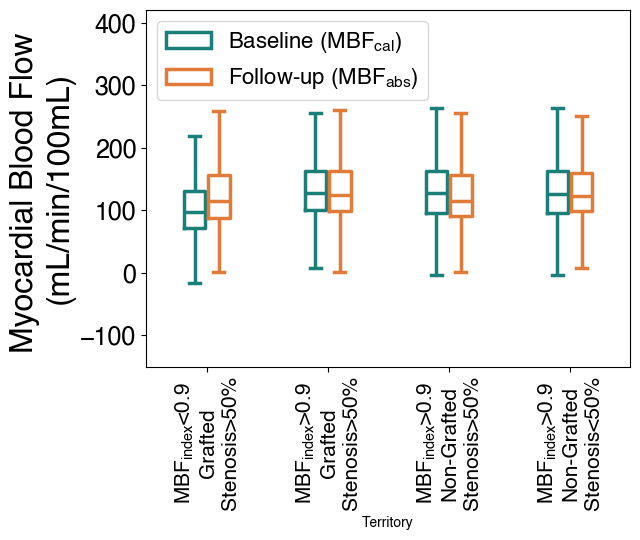

In [20]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4,  linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{cal}}$)':color1, 'Follow-up ($\\mathrm{MBF_{abs}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=20)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,420)
plt.tight_layout()
plt.show()

### Statistical Test

In [21]:
median_mbf_ischemic_A = []
median_mbf_ischemic_B = []

for _, row in df[df['is_ischemic'] == True].iterrows():
    median_mbf_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic_B.append(np.median(row['absMBF_B']))

p_value_ischemic = WilcoxonTest(median_mbf_ischemic_A, median_mbf_ischemic_B)

Wilcoxon test statistics:  9.0
p-value:  1.9669532775878906e-06
number of datapoints: 25
Reject the null hypothesis: There is a significant difference between the two samples.


In [22]:
median_mbf_nonischemic_A = []
median_mbf_nonischemic_B = []

for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")].iterrows():
    median_mbf_nonischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_nonischemic_B.append(np.median(row['absMBF_B']))

p_value_non_ischemic = WilcoxonTest(median_mbf_nonischemic_A, median_mbf_nonischemic_B)

Wilcoxon test statistics:  389.0
p-value:  0.14692974474753576
number of datapoints: 45
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [23]:
median_mbf_stng_A = []
median_mbf_stng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis>50%'].iterrows():
    median_mbf_stng_A.append(np.median(row['absMBF_A']))
    median_mbf_stng_B.append(np.median(row['absMBF_B']))

p_value_nongrafted_stenosis = WilcoxonTest(median_mbf_stng_A, median_mbf_stng_B)

Wilcoxon test statistics:  29.0
p-value:  0.7646484375
number of datapoints: 11
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [24]:
median_mbf_ng_A = []
median_mbf_ng_B = []

for _, row in df[df['tag'] == 'Non-grafted\nstenosis<50%'].iterrows():
    median_mbf_ng_A.append(np.median(row['absMBF_A']))
    median_mbf_ng_B.append(np.median(row['absMBF_B']))

p_value_nongrafted = WilcoxonTest(median_mbf_ng_A, median_mbf_ng_B)

Wilcoxon test statistics:  168.0
p-value:  0.8612560033798218
number of datapoints: 26
Fail to reject the null hypothesis: There is no significant difference between the two samples.


### Plot based on the severity ischemia

In [25]:
print("TerritoryTag", "Median", "IQR", "Mean", "std")
mbf_ischemic10_A = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_A, [25, 50, 75])
average = np.mean(mbf_ischemic10_A)
std = np.std(mbf_ischemic10_A)
print("ischemic_grafted10_A", q2, q3-q1, average, std)

mbf_ischemic10_B = np.concatenate(df[df['ischemic_grade'] == 1]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic10_B, [25, 50, 75])
average = np.mean(mbf_ischemic10_B)
std = np.std(mbf_ischemic10_B)
print("ischemic_grafted10_B",q2, q3-q1, average, std)

mbf_ischemic20_A = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_A, [25, 50, 75])
average = np.mean(mbf_ischemic20_A)
std = np.std(mbf_ischemic20_A)
print("ischemic_grafted20_A", q2, q3-q1, average, std)

mbf_ischemic20_B = np.concatenate(df[df['ischemic_grade'] == 2]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic20_B, [25, 50, 75])
average = np.mean(mbf_ischemic20_B)
std = np.std(mbf_ischemic20_B)
print("ischemic_grafted20_B",q2, q3-q1, average, std)

mbf_ischemic30_A = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_A, [25, 50, 75])
average = np.mean(mbf_ischemic30_A)
std = np.std(mbf_ischemic30_A)
print("ischemic_grafted30_A", q2, q3-q1, average, std)

mbf_ischemic30_B = np.concatenate(df[df['ischemic_grade'] == 3]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_ischemic30_B, [25, 50, 75])
average = np.mean(mbf_ischemic30_B)
std = np.std(mbf_ischemic30_B)
print("ischemic_grafted30_B",q2, q3-q1, average, std)

mbf_nonischemic_A = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_A'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_A, [25, 50, 75])
average = np.mean(mbf_nonischemic_A)
std = np.std(mbf_nonischemic_A)
print("nonischemic_grafted_A", q2, q3-q1, average, std)

mbf_nonischemic_B = np.concatenate(df[(df['ischemic_grade'] == 0) & (df['tag'] != 'Non-grafted\nstenosis<50%') & (df['tag'] != "Non-grafted\nstenosis>50%")]['absMBF_B'].values)
q1, q2, q3 = np.percentile(mbf_nonischemic_B, [25, 50, 75])
average = np.mean(mbf_nonischemic_B)
std = np.std(mbf_nonischemic_B)
print("nonischemic_grafted_B", q2, q3-q1, average, std)


TerritoryTag Median IQR Mean std
ischemic_grafted10_A 105.26077377294169 64.30690915076508 115.10839521629283 57.10176642715733
ischemic_grafted10_B 114.0 78.0 129.73047135176722 62.99765601596971
ischemic_grafted20_A 99.86290071636525 62.836031726339655 111.93664049928718 61.2305023542357
ischemic_grafted20_B 122.0 64.0 131.93042667481964 63.41269970092741
ischemic_grafted30_A 87.86290071636525 49.13484117073051 94.88894947893137 47.90168824344923
ischemic_grafted30_B 109.0 56.0 121.10250905469815 55.417114232449876
nonischemic_grafted_A 127.82283396973745 62.278136696048364 138.54691217005907 63.05288996799551
nonischemic_grafted_B 124.0 65.0 137.09344119733905 62.638494512004016


In [26]:
# Create a DataFrame with each part
df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_A, mbf_ischemic20_A, mbf_ischemic10_A, mbf_nonischemic_A]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_A) +
             ['0.7-0.8'] * len(mbf_ischemic20_A) +
             ['0.8-0.9'] * len(mbf_ischemic10_A) + 
             ['>0.9'] * len(mbf_nonischemic_A),  
    'Type': ['Baseline ($\\mathrm{MBF_{cal}}$)'] * (len(mbf_ischemic30_A) +len(mbf_ischemic20_A) +len(mbf_ischemic10_A) + len(mbf_nonischemic_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_ischemic30_B, mbf_ischemic20_B, mbf_ischemic10_B, mbf_nonischemic_B]),
    'Territory': ['<0.7'] * len(mbf_ischemic30_B) +
             ['0.7-0.8'] * len(mbf_ischemic20_B) +
             ['0.8-0.9'] * len(mbf_ischemic10_B) + 
             ['>0.9'] * len(mbf_nonischemic_B),
    'Type': ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * (len(mbf_ischemic30_B) + len(mbf_ischemic20_B) + len(mbf_ischemic10_B) + len(mbf_nonischemic_B))
})

# Combine into a single DataFrame
df_long = pd.concat([df_A, df_B], ignore_index=True)

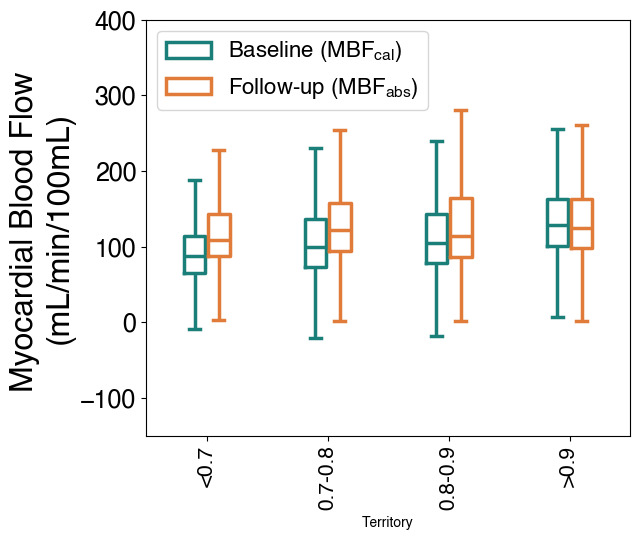

In [27]:
plt.figure(figsize=(6.5, 5.5))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4, linewidth=2.5, fill= False, gap=.1, palette={'Baseline ($\\mathrm{MBF_{cal}}$)':color1, 'Follow-up ($\\mathrm{MBF_{abs}}$)':color2})

ax.set_ylabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=90, labelsize=18)
ax.legend(loc = 'upper left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150,400)
plt.tight_layout()
plt.show()

### Statistical Test

In [28]:
median_mbf_ischemic10_A = []
median_mbf_ischemic10_B = []

for _, row in df[df['ischemic_grade'] == 1].iterrows():
    median_mbf_ischemic10_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic10_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic10_A, median_mbf_ischemic10_B)

Wilcoxon test statistics:  1.0
p-value:  0.03125
number of datapoints: 7
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.03125)

In [29]:
median_mbf_ischemic20_A = []
median_mbf_ischemic20_B = []

for _, row in df[df['ischemic_grade'] == 2].iterrows():
    median_mbf_ischemic20_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic20_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic20_A, median_mbf_ischemic20_B)

Wilcoxon test statistics:  5.0
p-value:  0.01953125
number of datapoints: 10
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.01953125)

In [30]:
median_mbf_ischemic30_A = []
median_mbf_ischemic30_B = []

for _, row in df[df['ischemic_grade'] == 3].iterrows():
    median_mbf_ischemic30_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic30_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic30_A, median_mbf_ischemic30_B)

Wilcoxon test statistics:  0.0
p-value:  0.0078125
number of datapoints: 8
Reject the null hypothesis: There is a significant difference between the two samples.


np.float64(0.0078125)

In [31]:
median_mbf_ischemic0_A = []
median_mbf_ischemic0_B = []

for _, row in df[df['ischemic_grade'] == 0].iterrows():
    median_mbf_ischemic0_A.append(np.median(row['absMBF_A']))
    median_mbf_ischemic0_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_ischemic0_A, median_mbf_ischemic0_B)

Wilcoxon test statistics:  1445.0
p-value:  0.23570506605331942
number of datapoints: 82
Fail to reject the null hypothesis: There is no significant difference between the two samples.


np.float64(0.23570506605331942)

## Statistical Analysis: Per vessel 

In [32]:
df[(df["patient_id"] == "SU03") & (df["tag"] == "Diag")]["is_ischemic"].iloc[0]

np.True_

In [33]:
print(len(df["tag"]))

107


In [34]:
ischemic_territories = []
nonischemic_territories = []

ischemic_median_A = []
ischemic_median_B = []
nonischemic_median_A = []
nonischemic_median_B = []

nongrafted_median_A = []
nongrafted_median_B = []

grafted_median_A = []
grafted_median_B = []

nonischemic_grafted_A = []
nonischemic_grafted_B = []

for id in patient_ids:
    tags = list(df[df["patient_id"] == id]["tag"])
    df_patient = df[df["patient_id"] == id]
    if df_patient.empty:
        print(f"Patient {patient_id} not found in DataFrame. Skipping.")
        continue

    for tag in tags:
        median_absMBF_A = np.median(np.concatenate(df[(df["patient_id"] == id) & (df["tag"] == tag)]["absMBF_A"].values))
        median_absMBF_B = np.median(np.concatenate(df[(df["patient_id"] == id) & (df["tag"] == tag)]["absMBF_B"].values))
        
        if df[(df["patient_id"] == id) & (df["tag"] == tag)]["is_ischemic"].iloc[0] == True:
            ischemic_median_A.append(median_absMBF_A)
            ischemic_median_B.append(median_absMBF_B)
            """ischemic_territories.append({"patient_id": id,
                                        "tag": tag,
                                        "median_absMBF_A": median_absMBF_A,
                                        "median_absMBF_B": median_absMBF_B})"""
        else:
            nonischemic_median_A.append(median_absMBF_A)
            nonischemic_median_B.append(median_absMBF_B)
            """nonischemic_territories.append({"patient_id": id,
                                        "tag": tag,
                                        "median_absMBF_A": median_absMBF_A,
                                        "median_absMBF_B": median_absMBF_B})"""
            if tag not in ["Non-grafted\nstenosis<50%", "Non-grafted\nstenosis>50%"]:
                nonischemic_grafted_A.append(median_absMBF_A)
                nonischemic_grafted_B.append(median_absMBF_B)
        
        if tag in ["Non-grafted\nstenosis<50%", "Non-grafted\nstenosis>50%"]:
            nongrafted_median_A.append(median_absMBF_A)
            nongrafted_median_B.append(median_absMBF_B)
        else:
            grafted_median_A.append(median_absMBF_A)
            grafted_median_B.append(median_absMBF_B)


#ischemic_territories = pd.DataFrame(ischemic_territories)
#nonischemic_territories = pd.DataFrame(nonischemic_territories)

Patient VA20 not found in DataFrame. Skipping.
Patient VA20 not found in DataFrame. Skipping.


In [35]:
print(len(grafted_median_A))

70


In [36]:
w_value, p_value = wilcoxon(ischemic_median_A, ischemic_median_B)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(ischemic_median_A))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


Wilcoxon test statistics:  9.0
p-value:  1.9669532775878906e-06
number of datapoints: 25
Reject the null hypothesis: There is a significant difference between the two samples.


In [37]:
w_value, p_value = wilcoxon(nonischemic_median_A, nonischemic_median_B)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(ischemic_median_A))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


Wilcoxon test statistics:  1445.0
p-value:  0.23570506605331942
number of datapoints: 25
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [38]:
w_value, p_value = wilcoxon(nongrafted_median_A, nongrafted_median_B)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(nongrafted_median_A))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


Wilcoxon test statistics:  350.0
p-value:  0.9819450988484374
number of datapoints: 37
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [39]:
w_value, p_value = wilcoxon(grafted_median_A, grafted_median_B)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(grafted_median_A))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


Wilcoxon test statistics:  551.0
p-value:  5.192413195772484e-05
number of datapoints: 70
Reject the null hypothesis: There is a significant difference between the two samples.


In [40]:
w_value, p_value = wilcoxon(nonischemic_grafted_A, nonischemic_grafted_B)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(nonischemic_grafted_A))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


Wilcoxon test statistics:  389.0
p-value:  0.14692974474753576
number of datapoints: 45
Fail to reject the null hypothesis: There is no significant difference between the two samples.


In [41]:
entire_territories_A = [*ischemic_median_A, *nonischemic_median_A]
entire_territories_B = [*ischemic_median_B, *nonischemic_median_B]

w_value, p_value = wilcoxon(entire_territories_A, entire_territories_B)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(entire_territories_A))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


Wilcoxon test statistics:  1759.0
p-value:  0.00044464148644226
number of datapoints: 107
Reject the null hypothesis: There is a significant difference between the two samples.


### Scatter Plot

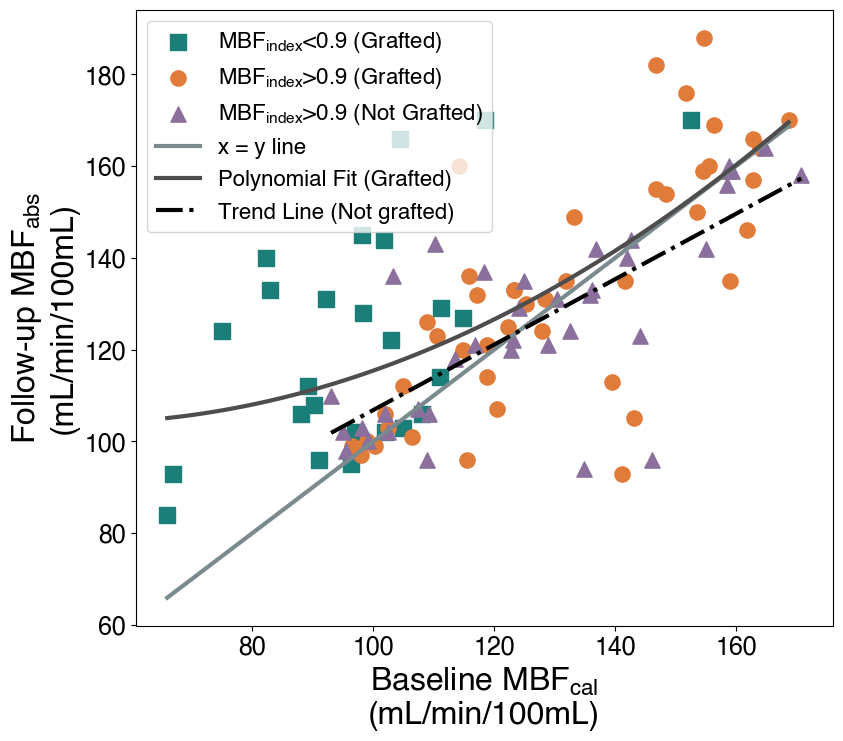

In [42]:
plt.figure(figsize=(9, 8))

plt.scatter(ischemic_median_A, ischemic_median_B, marker = 's', s = 120, color = color1, label = '$\\mathrm{MBF_{index}}$<0.9 (Grafted)')
plt.scatter(nonischemic_grafted_A, nonischemic_grafted_B, marker = 'o', s = 120, color = color2, label = "$\\mathrm{MBF_{index}}$>0.9 (Grafted)")
plt.scatter(nongrafted_median_A, nongrafted_median_B, marker = '^', s = 120, color = color7, label = "$\\mathrm{MBF_{index}}$>0.9 (Not Grafted)")

x_fit = np.linspace(min(grafted_median_A), max(grafted_median_A), 100)
plt.plot(x_fit, x_fit, '-',color = color6, linewidth=3, label = "x = y line")

deg = 2
poly = PolynomialFeatures(degree=deg)
x_poly = poly.fit_transform(np.array(grafted_median_A).reshape(-1,1))

LinReg = LinearRegression()
LinReg.fit(x_poly, np.array(grafted_median_B))

x_new = np.linspace(np.array(grafted_median_A).min(), np.array(grafted_median_A).max(), 100).reshape(-1,1)
x_new_poly = poly.transform(x_new)
y_pred = LinReg.predict(x_new_poly)

plt.plot(x_new, y_pred, color = color10, linewidth=3, label=f"Polynomial Fit (Grafted)")

x_fit = np.linspace(min(nongrafted_median_A), max(nongrafted_median_A), 100)

slope, intercept, _, _, _ = linregress(nongrafted_median_A, nongrafted_median_B)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, '-.', color="black", linewidth=3, label= "Trend Line (Not grafted)")

#font1 = {'color':'black','size':23, 'family':'Times New Roman'}
#plt.rcParams['font.family'] = 'Times New Roman'

plt.xlabel("Baseline $\\mathrm{MBF_{cal}}$\n(mL/min/100mL)", fontdict = font1)
plt.ylabel("Follow-up $\\mathrm{MBF_{abs}}$\n(mL/min/100mL)", fontdict = font1)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.legend(fontsize = 16)
plt.show()

# Thresholding on index MBF

In [43]:
volume_data_ischemic = []
volume_data_nonischemic = []
Removed_Cases_volume = Removed_Cases + ['SU03']
for patient_id in patient_ids:
    if patient_id in Removed_Cases_volume: 
        continue
    
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = Normalize(ReadVTUFile(file), normalization_method)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method)

    nonischemic_grid_A = ThresholdByUpper(MBF_A, "IndexMBF", 0.9)
    nonischemic_grid_B = ThresholdByUpper(MBF_B, "IndexMBF", 0.9)

    IschemicVolume_A = (GetVolume(MBF_A) - GetVolume(nonischemic_grid_A))/GetVolume(MBF_A)*100
    IschemicVolume_B = (GetVolume(MBF_B) - GetVolume(nonischemic_grid_B))/GetVolume(MBF_B)*100

    ischemia_presence = list(df[df["patient_id"] == patient_id]["is_ischemic"])
    is_ischemic = any(ischemia_presence)
    if is_ischemic:
        volume_data_ischemic.append({
            "patient_id": patient_id,
            "Volume_A": IschemicVolume_A,
            "Volume_B": IschemicVolume_B
        })
    else:
        volume_data_nonischemic.append({
            "patient_id": patient_id,
            "Volume_A": IschemicVolume_A,
            "Volume_B": IschemicVolume_B
        })

volume_data_ischemic = pd.DataFrame(volume_data_ischemic)
volume_data_nonischemic = pd.DataFrame(volume_data_nonischemic)

volume_entire_cohort = pd.concat([volume_data_ischemic, volume_data_nonischemic], ignore_index=True)

In [44]:
df_A = pd.DataFrame({
    'Volume': np.concatenate([volume_data_ischemic["Volume_A"], volume_data_nonischemic["Volume_A"], volume_entire_cohort["Volume_A"]]),
    'Case': ['Ischemic\n Cases'] * len(volume_data_ischemic["Volume_A"]) +
            ['NonIschemic\n Cases'] * len(volume_data_nonischemic["Volume_A"]) +
            ['Entire Cohort'] * len(volume_entire_cohort["Volume_A"]),
    'Type': ['Pre-CABG'] * (len(volume_data_ischemic["Volume_A"]) + len(volume_data_nonischemic["Volume_A"]) + len(volume_entire_cohort["Volume_A"]))
})

df_B = pd.DataFrame({
    'Volume': np.concatenate([volume_data_ischemic["Volume_B"], volume_data_nonischemic["Volume_B"], volume_entire_cohort["Volume_B"]]),
    'Case': ['Ischemic\n Cases'] * len(volume_data_ischemic["Volume_B"]) +
            ['NonIschemic\n Cases'] * len(volume_data_nonischemic["Volume_B"]) +
            ['Entire Cohort'] * len(volume_entire_cohort["Volume_B"]),
    'Type': ['Post-CABG'] * (len(volume_data_ischemic["Volume_B"]) + len(volume_data_nonischemic["Volume_B"]) + len(volume_entire_cohort["Volume_B"]))
})

df_long = pd.concat([df_A, df_B], ignore_index=True)

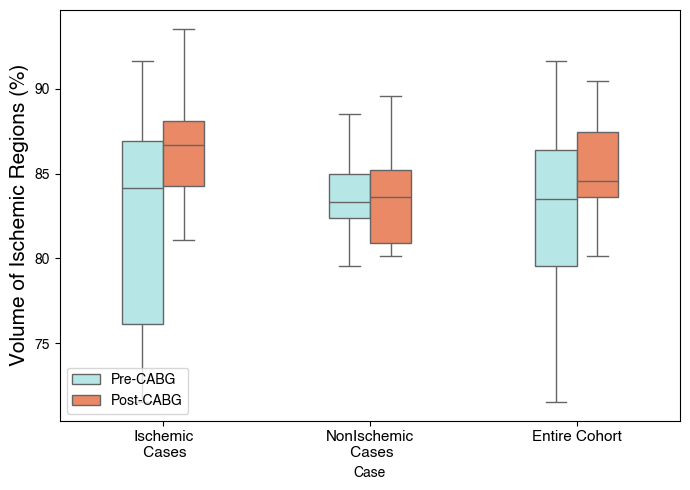

In [45]:
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x='Case', y='Volume', hue='Type', data= df_long, showfliers=False, width = 0.4, palette={'Pre-CABG':'paleturquoise', 'Post-CABG':'coral'})

ax.set_ylabel("Volume of Ischemic Regions (%)", fontsize = 15)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.legend(loc = 'lower left')
plt.tight_layout()
plt.show()

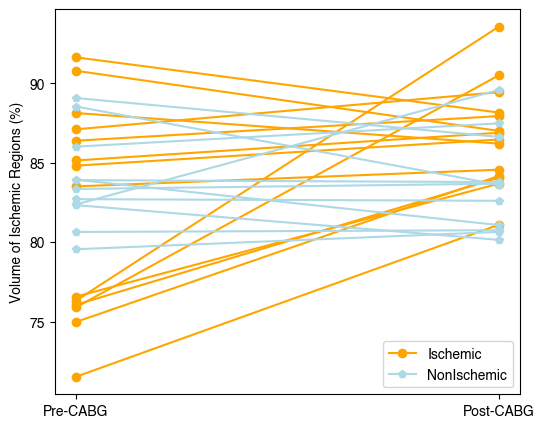

In [46]:
plt.figure(figsize=(6,5))

for i in range(len(volume_data_ischemic)):
    if i == 0:
        plt.plot([0, 1], [volume_data_ischemic["Volume_A"][i], volume_data_ischemic["Volume_B"][i]], marker = "o", color = "orange", label = "Ischemic")
    else:
        plt.plot([0, 1], [volume_data_ischemic["Volume_A"][i], volume_data_ischemic["Volume_B"][i]], marker = "o", color = "orange", label = None)
for i in range(len(volume_data_nonischemic)):
    if i == 0:
        plt.plot([0, 1], [volume_data_nonischemic["Volume_A"][i], volume_data_nonischemic["Volume_B"][i]], marker = "p", color = "lightblue", label = "NonIschemic")
    else:
        plt.plot([0, 1], [volume_data_nonischemic["Volume_A"][i], volume_data_nonischemic["Volume_B"][i]], marker = "p", color = "lightblue", label = None)
plt.xticks([0, 1], ["Pre-CABG", "Post-CABG"])
plt.ylabel("Volume of Ischemic Regions (%)")
plt.legend()
plt.show()

In [47]:
def GetStats(dataframe):
    q1, q2, q3 = np.percentile(dataframe, [25, 50, 75])
    average = np.mean(dataframe)
    std = np.std(dataframe)
    return q2, q3-q1, average, std

print("TerritoryTag", "Median", "IQR", "Mean", "std")
volume_ischemic_A = np.concatenate([volume_data_ischemic["Volume_A"]])
print("Volume of Ischemic Regions (Ischemic Cases) Pre-CABG: ", GetStats(volume_ischemic_A))

volume_ischemic_B = np.concatenate([volume_data_ischemic["Volume_B"]])
print("Volume of Ischemic Regions (Ischemic Cases) Post-CABG: ", GetStats(volume_ischemic_B))

volume_nonischemic_A = np.concatenate([volume_data_nonischemic["Volume_A"]])
print("Volume of Ischemic Regions (Nonischemic Cases) Pre-CABG: ", GetStats(volume_nonischemic_A))

volume_nonischemic_B = np.concatenate([volume_data_nonischemic["Volume_B"]])
print("Volume of Ischemic Regions (Nonischemic Cases) Post-CABG: ", GetStats(volume_nonischemic_B))

EntireCohort_A = np.concatenate([volume_entire_cohort["Volume_A"]])
print("Volume of Ischemic Regions (Entire Dataset) Pre-CABG: ", GetStats(EntireCohort_A))

EntireCohort_B = np.concatenate([volume_entire_cohort["Volume_B"]])
print("Volume of Ischemic Regions (Entire Dataset) Post-CABG: ", GetStats(EntireCohort_B))

TerritoryTag Median IQR Mean std
Volume of Ischemic Regions (Ischemic Cases) Pre-CABG:  (np.float64(84.16651893996422), np.float64(10.796594720356481), np.float64(82.06668107800608), np.float64(6.3569242532448085))
Volume of Ischemic Regions (Ischemic Cases) Post-CABG:  (np.float64(86.67713896808769), np.float64(3.8354822935956037), np.float64(86.69649414809201), np.float64(3.0642951021520104))
Volume of Ischemic Regions (Nonischemic Cases) Pre-CABG:  (np.float64(83.35372968128505), np.float64(2.618095595848203), np.float64(83.86154226125483), np.float64(2.8390796826694116))
Volume of Ischemic Regions (Nonischemic Cases) Post-CABG:  (np.float64(83.62363804324437), np.float64(4.2893217348625114), np.float64(83.64067492967382), np.float64(2.95460521944402))
Volume of Ischemic Regions (Entire Dataset) Pre-CABG:  (np.float64(83.51382315409631), np.float64(6.828143744593845), np.float64(82.85641999863554), np.float64(5.193286110433114))
Volume of Ischemic Regions (Entire Dataset) Post-CABG:

# Analyzing Based on the Graft Type

In [48]:
grafts = sorted(set(PatientMetadata["graft"]))
print(grafts)

['LIMA', 'RIMA', 'Radial', 'SVG', 'n']


In [49]:
print(PatientMetadata["graft"].value_counts())

graft
SVG       37
LIMA      26
Radial    10
RIMA       1
n          1
Name: count, dtype: int64


In [50]:
print(len(df["tag"]))
print(df["tag"].value_counts())
mask = (df["tag"] != "Not grafted") & (df["tag"] != "Not grafted\nstenosis>50%")
print(len(df.loc[mask, "tag"]))
print(df.loc[mask, "tag"].value_counts())

107
tag
LAD                          26
Non-grafted\nstenosis<50%    26
RCA                          19
LCx                          14
Non-grafted\nstenosis>50%    11
Diag                          3
OM                            3
PDA                           3
Ramus                         2
Name: count, dtype: int64
107
tag
LAD                          26
Non-grafted\nstenosis<50%    26
RCA                          19
LCx                          14
Non-grafted\nstenosis>50%    11
Diag                          3
OM                            3
PDA                           3
Ramus                         2
Name: count, dtype: int64


In [51]:
print(PatientMetadata["NG"].value_counts())

NG
n        59
LCx       6
PDA       2
Diag1     2
IM        1
OM1       1
IM_0      1
m         1
PL        1
RCA       1
Name: count, dtype: int64


In [52]:
LIMA_mbf_A = np.concatenate(df[df['graft_type'] == 'LIMA']['absMBF_A'].values)
LIMA_mbf_B = np.concatenate(df[df['graft_type'] == 'LIMA']['absMBF_B'].values)

Radial_mbf_A = np.concatenate(df[df['graft_type'] == 'Radial']['absMBF_A'].values)
Radial_mbf_B = np.concatenate(df[df['graft_type'] == 'Radial']['absMBF_B'].values)

SVG_mbf_A = np.concatenate(df[df['graft_type'] == 'SVG']['absMBF_A'].values)
SVG_mbf_B = np.concatenate(df[df['graft_type'] == 'SVG']['absMBF_B'].values)

## Comparing the volume fed by each graft

In [53]:
LIMA_volume_A = []
LIMA_volume_B = []

Radial_volume_A = []
Radial_volume_B = []

SVG_volume_A = []
SVG_volume_B = []

Removed_Cases_volume = Removed_Cases + ['SU03']

for patient_id in patient_ids:
    if patient_id in Removed_Cases_volume: 
        continue
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "classic"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = Normalize(ReadVTUFile(file), normalization_method)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method)

        for tag in tags:
            graft = PatientMetadata[(PatientMetadata['patient-id'] == patient_id) & (PatientMetadata['stenosis tag'] == tag)]['graft']
            if graft.iloc[0] == 'LIMA':
                LIMA_volume_A.append(GetRegionVolume(MBF_A, MBF_Labels, tag))
                LIMA_volume_B.append(GetRegionVolume(MBF_B, MBF_Labels, tag))
            if graft.iloc[0] == 'Radial':
                Radial_volume_A.append(GetRegionVolume(MBF_A, MBF_Labels, tag))
                Radial_volume_B.append(GetRegionVolume(MBF_B, MBF_Labels, tag))
            if graft.iloc[0] == 'SVG':
                SVG_volume_A.append(GetRegionVolume(MBF_A, MBF_Labels, tag))
                SVG_volume_B.append(GetRegionVolume(MBF_B, MBF_Labels, tag))

LIMA_volume_A = np.array(LIMA_volume_A)
LIMA_volume_B = np.array(LIMA_volume_B)

Radial_volume_A = np.array(Radial_volume_A)
Radial_volume_B = np.array(Radial_volume_B)

SVG_volume_A = np.array(SVG_volume_A)
SVG_volume_B = np.array(SVG_volume_B)



## Statistical Analysis: Kruskal-Wallis test on the differences of median MBF per graft type

In [54]:
LIMA_d_median_mbf = []
Radial_d_median_mbf = []
SVG_d_median_mbf = []

for patient_id in patient_ids:
    df_patient = df[df["patient_id"] == patient_id]
    if df_patient.empty:
        print(f"Patient {patient_id} not found in DataFrame. Skipping.")
        continue
    
    grafts = list(df[df["patient_id"] == patient_id]["graft_type"])
    for graft in grafts:
        if graft:
            median_A = np.median(df[(df["patient_id"] == patient_id) & (df["graft_type"] == graft)]["absMBF_A"].iloc[0])
            median_B = np.median(df[(df["patient_id"] == patient_id) & (df["graft_type"] == graft)]["absMBF_B"].iloc[0])
        diff = median_B - median_A
        if graft == "LIMA":
            LIMA_d_median_mbf.append(diff)
        elif graft == "Radial":
            Radial_d_median_mbf.append(diff)
        elif graft == "SVG":
            SVG_d_median_mbf.append(diff)
        else:
            pass



IndexError: single positional indexer is out-of-bounds

In [ ]:
stat, p = kruskal(LIMA_d_median_mbf, Radial_d_median_mbf, SVG_d_median_mbf)
print(p)
if p > 0.05:
    print("There is no significant difference in improvement (ΔMBF) between different graft types.")
else:
    print("There is a difference—at least one graft type shows a significantly different median improvement.")

# Territory-based analysis

In [ ]:
def TerritorySelection(tag):
    if any(sub in tag.lower() for sub in ["lcx", "om", "intermedius"]):
        territory = "LCx"
    elif any(sub in tag.lower() for sub in ["lad", "diag"]):
        territory = "LAD"
    elif any(sub in tag.lower() for sub in ["pda", "pl"]):
        territory = "RCA"
    else:
        print(f"{tag} was not assigned to any specific territory.")
        territory = None
    
    return territory

def TerritoryAssignment(MBF, InputLabels, ScalarArray):
    
    Territories = {"LAD":None, "LCx":None, "RCA":None}
    Territory_ids = {"LAD":[], "LCx":[], "RCA":[]}
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])

            
            territory_tag = TerritorySelection(label)
            if territory_tag is not None:
                Territory_ids[territory_tag].append(id_value)
    
    for tag, ids in Territory_ids.items():
        TerritoryAppend = vtk.vtkAppendFilter()
        for id in ids:
            territory = ThresholdInBetween(MBF, "TerritoryMaps", id, id)
            TerritoryAppend.AddInputData(territory)
        TerritoryAppend.Update()
        Territory = TerritoryAppend.GetOutput()
        MBFArray = vtk_to_numpy(Territory.GetPointData().GetArray(ScalarArray))
        Territories[tag] = MBFArray

    return Territories


MappedVTUFiles = glob.glob(f"{opath}/*.vtu")

LAD_MBF_A = []
LAD_MBF_B = []

LCx_MBF_A = []
LCx_MBF_B = []

RCA_MBF_A = []
RCA_MBF_B = []
Removed_Cases_ = Removed_Cases + ["VA13"]
for patient_id in patient_ids:
    if patient_id in Removed_Cases_: 
        continue
    print(patient_id)

    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file

    for file in MappedVTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
    for file in VTUFiles:
        if f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    
    for i in range(MBF_B.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF_B.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray_B = arrayname_
    
    MappedScalarArrayName = "MappedScalar"
    territory_A = TerritoryAssignment(MBF_A, LabelFile, MappedScalarArrayName)
    territory_B = TerritoryAssignment(MBF_B, LabelFile, ScalarArray_B)

    LAD_MBF_A.append(territory_A["LAD"])
    LAD_MBF_B.append(territory_B["LAD"])

    LCx_MBF_A.append(territory_A["LCx"])
    LCx_MBF_B.append(territory_B["LCx"])

    RCA_MBF_A.append(territory_A["RCA"])
    RCA_MBF_B.append(territory_B["RCA"])

LAD_MBF_A = np.concatenate(LAD_MBF_A)
LAD_MBF_B = np.concatenate(LAD_MBF_B)

LCx_MBF_A = np.concatenate(LCx_MBF_A)
LCx_MBF_B = np.concatenate(LCx_MBF_B)

RCA_MBF_A = np.concatenate(RCA_MBF_A)
RCA_MBF_B = np.concatenate(RCA_MBF_B)

# Territory-Based Analysis Downstream a Stenosis

In [ ]:
tags_unique = sorted(set(PatientMetadata["stenosis tag"]))
print(tags_unique)

In [ ]:
tags_dataframe = sorted(set(df["tag"]))
print(tags_dataframe)

In [ ]:
#Is ischemic

LAD_MBF_A = np.concatenate(df[(df["tag"].isin(["LAD", "Diag"])) & (df["is_ischemic"] == True)]["absMBF_A"].values)
LAD_MBF_B = np.concatenate(df[(df["tag"].isin(["LAD", "Diag"]))& (df["is_ischemic"] == True)]["absMBF_B"].values)

LCx_MBF_A = np.concatenate(df[(df["tag"].isin(["LCx", "Ramus", "OM"])) & (df["is_ischemic"] == True)]["absMBF_A"].values)
LCx_MBF_B = np.concatenate(df[(df["tag"].isin(["LCx", "Ramus", "OM"])) & (df["is_ischemic"] == True)]["absMBF_B"].values)

RCA_MBF_A = np.concatenate(df[(df["tag"].isin(["PDA", "RCA"])) & (df["is_ischemic"] == True)]["absMBF_A"].values)
RCA_MBF_B = np.concatenate(df[(df["tag"].isin(["PDA", "RCA"])) & (df["is_ischemic"] == True)]["absMBF_B"].values)

In [ ]:
#statistical analysis
mask = (df["tag"].isin(["LAD", "Diag"])) & (df["is_ischemic"] == True)
LAD_MBF_A_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_A"]])
LAD_MBF_B_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_B"]])

mask = (df["tag"].isin(["LCx", "Ramus", "OM"])) & (df["is_ischemic"] == True)
LCx_MBF_A_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_A"]])
LCx_MBF_B_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_B"]])

mask = (df["tag"].isin(["PDA", "RCA"])) & (df["is_ischemic"] == True)
RCA_MBF_A_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_A"]])
RCA_MBF_B_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_B"]])

In [ ]:
w_value, p_value = wilcoxon(LAD_MBF_A_median, LAD_MBF_B_median)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(LAD_MBF_A_median))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


In [ ]:
w_value, p_value = wilcoxon(LCx_MBF_A_median, LCx_MBF_B_median)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(LCx_MBF_A_median))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


In [ ]:
w_value, p_value = wilcoxon(RCA_MBF_A_median, RCA_MBF_B_median)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(RCA_MBF_A_median))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


In [ ]:
#Is not ischemic

LAD_MBF_A = np.concatenate(df[(df["tag"].isin(["LAD", "Diag"])) & (df["is_ischemic"] == False)]["absMBF_A"].values)
LAD_MBF_B = np.concatenate(df[(df["tag"].isin(["LAD", "Diag"]))& (df["is_ischemic"] == False)]["absMBF_B"].values)

LCx_MBF_A = np.concatenate(df[(df["tag"].isin(["LCx", "Ramus", "OM"])) & (df["is_ischemic"] == False)]["absMBF_A"].values)
LCx_MBF_B = np.concatenate(df[(df["tag"].isin(["LCx", "Ramus", "OM"])) & (df["is_ischemic"] == False)]["absMBF_B"].values)

RCA_MBF_A = np.concatenate(df[(df["tag"].isin(["PDA", "RCA"])) & (df["is_ischemic"] == False)]["absMBF_A"].values)
RCA_MBF_B = np.concatenate(df[(df["tag"].isin(["PDA", "RCA"])) & (df["is_ischemic"] == False)]["absMBF_B"].values)

In [ ]:
#statistical analysis
mask = (df["tag"].isin(["LAD", "Diag"])) & (df["is_ischemic"] == False)
LAD_MBF_A_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_A"]])
LAD_MBF_B_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_B"]])

mask = (df["tag"].isin(["LCx", "Ramus", "OM"])) & (df["is_ischemic"] == False)
LCx_MBF_A_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_A"]])
LCx_MBF_B_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_B"]])

mask = (df["tag"].isin(["PDA", "RCA"])) & (df["is_ischemic"] == False)
RCA_MBF_A_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_A"]])
RCA_MBF_B_median = np.array([np.median(arr) for arr in df.loc[mask, "absMBF_B"]])

In [ ]:
w_value, p_value = wilcoxon(LAD_MBF_A_median, LAD_MBF_B_median)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(LAD_MBF_A_median))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


In [ ]:
w_value, p_value = wilcoxon(LCx_MBF_A_median, LCx_MBF_B_median)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(LCx_MBF_A_median))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


In [ ]:
w_value, p_value = wilcoxon(RCA_MBF_A_median, RCA_MBF_B_median)
print("Wilcoxon test statistics: ", w_value)
print("p-value: ", p_value)
print("number of datapoints:", len(RCA_MBF_A_median))

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference between the two samples.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")


# Bland Altman plot of Hypoperfusion Pre/Post-CABG

In [ ]:
for file in MappedVTUFiles:
    if f"SU03A" in os.path.basename(os.path.splitext(file)[0]):
        MBF_A = ReadVTUFile(file)
    elif f"SU03B" in os.path.basename(os.path.splitext(file)[0]):
        MBF_B = ReadVTUFile(file)

ScalarArray_A_Name = "ImageScalars"

ScalarArray_A = vtk_to_numpy(MBF_A.GetPointData().GetArray(MappedScalarArrayName))#ScalarArray_A_Name))#
IndexMBF_A = ScalarArray_A/np.percentile(ScalarArray_A, 75)

IschemicMask_A = IndexMBF_A < 0.5

print(len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A))


ScalarArray_B_Name = "scalars"

ScalarArray_B = vtk_to_numpy(MBF_B.GetPointData().GetArray(ScalarArray_B_Name))
IndexMBF_B = ScalarArray_B/np.percentile(ScalarArray_B, 75)

IschemicMask_B = IndexMBF_B < 0.5

print(len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B))

In [ ]:
IschemicCount_A_Ischemic = []
IschemicCount_B_Ischemic = []

IschemicCount_A_nonIschemic = []
IschemicCount_B_nonIschemic = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue

    for file in MappedVTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)

    ScalarArray_A_Name = "ImageScalars"

    ScalarArray_A = vtk_to_numpy(MBF_A.GetPointData().GetArray(MappedScalarArrayName))#ScalarArray_A_Name))#
    IndexMBF_A = ScalarArray_A/np.percentile(ScalarArray_A, 75)

    IschemicMask_A = IndexMBF_A < 0.6



    ScalarArray_B_Name = "scalars"

    ScalarArray_B = vtk_to_numpy(MBF_B.GetPointData().GetArray(ScalarArray_B_Name))
    IndexMBF_B = ScalarArray_B/np.percentile(ScalarArray_B, 75)

    IschemicMask_B = IndexMBF_B < 0.6


    ischemia_presence = list(df[df["patient_id"] == patient_id]["is_ischemic"])
    is_ischemic = any(ischemia_presence)


    if is_ischemic:
        IschemicCount_A_Ischemic.append(len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A))
        IschemicCount_B_Ischemic.append(len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B))
    else:
        IschemicCount_A_nonIschemic.append(len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A))
        IschemicCount_B_nonIschemic.append(len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B))

In [ ]:
IschemicCount_A_Ischemic = np.array(IschemicCount_A_Ischemic)
IschemicCount_B_Ischemic = np.array(IschemicCount_B_Ischemic)


IschemicCount_A_nonIschemic = np.array(IschemicCount_A_nonIschemic)
IschemicCount_B_nonIschemic = np.array(IschemicCount_B_nonIschemic)

IschemicCount_A = np.concatenate((IschemicCount_A_Ischemic, IschemicCount_A_nonIschemic), axis = 0)
IschemicCount_B = np.concatenate((IschemicCount_B_Ischemic, IschemicCount_B_nonIschemic), axis = 0)

In [ ]:
print(IschemicCount_A_Ischemic)
print(IschemicCount_B_Ischemic)

diff_Ischemic = IschemicCount_B_Ischemic - IschemicCount_A_Ischemic
print(diff_Ischemic)

print(IschemicCount_A_nonIschemic)
print(IschemicCount_B_nonIschemic)
diff_nonIschemic = IschemicCount_B_nonIschemic - IschemicCount_A_nonIschemic
print(diff_nonIschemic)

# Bland-Altmans of the Volume

## Only Ischemic Regions

In [ ]:
threshold = 0.9
Array_A = np.array([])
Array_B = np.array([])

Array_A_70 = np.array([])
Array_B_70 = np.array([])

Array_A_80 = np.array([])
Array_B_80 = np.array([])

Array_A_90 = np.array([])
Array_B_90 = np.array([])

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    ischemia_presence = list(df[df["patient_id"] == patient_id]["is_ischemic"])
    is_ischemic = any(ischemia_presence)


    if is_ischemic:
        ScalarArray_A = np.concatenate(df[(df["patient_id"] == patient_id) & (df["is_ischemic"] == True)]["absMBF_A"].values)
        
        ScalarArray_B = np.concatenate(df[(df["patient_id"] == patient_id) & (df["is_ischemic"] == True)]["absMBF_B"].values)

        RemoteMedian_A = np.percentile(np.concatenate(df[(df["patient_id"] == patient_id) & (df["tag"] == "Non-grafted\nstenosis<50%")]["absMBF_A"].values), 75)
        RemoteMedian_B = np.percentile(np.concatenate(df[(df["patient_id"] == patient_id) & (df["tag"] == "Non-grafted\nstenosis<50%")]["absMBF_B"].values), 75)

        IndexMBF_A = ScalarArray_A/RemoteMedian_A
        IschemicMask_A = IndexMBF_A < threshold

        IndexMBF_B = ScalarArray_B/RemoteMedian_B
        IschemicMask_B = IndexMBF_B < threshold
        

        Array_A = np.append(Array_A, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
        Array_B = np.append(Array_B, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

        IschemicMask_A = IndexMBF_A < 0.7
        IschemicMask_B = IndexMBF_B < 0.7

        Array_A_70 = np.append(Array_A_70, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
        Array_B_70 = np.append(Array_B_70, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

        IschemicMask_A = (0.7<IndexMBF_A)&(IndexMBF_A< 0.8)
        IschemicMask_B = (0.7<IndexMBF_B)&(IndexMBF_B< 0.8)

        Array_A_80 = np.append(Array_A_80, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
        Array_B_80 = np.append(Array_B_80, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

        IschemicMask_A = (0.8<IndexMBF_A)&(IndexMBF_A< 0.9)
        IschemicMask_B = (0.8<IndexMBF_B)&(IndexMBF_B< 0.9)

        Array_A_90 = np.append(Array_A_90, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
        Array_B_90 = np.append(Array_B_90, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

In [ ]:
mean = np.mean([Array_A, Array_B], axis = 0)
diff = Array_B - Array_A
md = np.mean(diff) # Mean of difference
sd = np.std(diff, ddof = 1) #standard deviation of difference

#plt.scatter(mean, diff, color="mediumvioletred", marker = 's', s = 80, label = '$\\mathrm{MBF_{index}}$<0.9 (Grafted)')
mean_70 = np.mean([Array_A_70, Array_B_70], axis = 0)
diff_70 = Array_B_70 - Array_A_70
plt.scatter(mean_70, diff_70, color=color_set1[0], s = 80, marker = 's', label = '$\\mathrm{MBF_{index}}$<0.7 (Grafted)')

mean_80 = np.mean([Array_A_80, Array_B_80], axis = 0)
diff_80 = Array_B_80 - Array_A_80
plt.scatter(mean_80, diff_80, color=color_set1[1], s = 80, marker = 'o', label = '0.7<$\\mathrm{MBF_{index}}$<0.8 (Grafted)')

mean_90 = np.mean([Array_A_90, Array_B_90], axis = 0)
diff_90 = Array_B_90 - Array_A_90
plt.scatter(mean_90, diff_90, color=color_set1[2], s = 80, marker = '^', label = '0.8<$\\mathrm{MBF_{index}}$<0.9 (Grafted)')

loa_upper = md + 1.96*sd
loa_lower = md - 1.96*sd

plt.text(40, loa_upper + 0.002, f'+1.96 σ = {loa_upper:.2f}', color='gray', va='bottom', fontsize = 20)
plt.text(40, loa_lower - 0.002, f'-1.96 σ = {loa_lower:.2f}', color='gray', va='top',  fontsize = 20)
plt.text(40, md + 0.002, f'{md:.2f} $\pm$ {sd:.2f}', color='gray', va='bottom',  fontsize = 20)


plt.axhline(np.mean(diff_70), color = color_set1[0], alpha = 0.5)
plt.axhline(np.mean(diff_80), color = color_set1[1], alpha = 0.5)
plt.axhline(np.mean(diff_90), color = color_set1[2], alpha = 0.5)
plt.axhline(md, color='gray', linestyle='--')
plt.axhline(loa_upper, color='gray', linestyle='--')
plt.axhline(loa_lower, color='gray', linestyle='--')
plt.xlabel("Mean of normalized volume (%)\n(Baseline + Follow-up)/2", fontdict=font2)
plt.ylabel("Normalized volume (%)\n(Follow-up  – Baseline)", fontdict=font2)
plt.xticks(fontsize = 23)
plt.yticks(fontsize = 23)
plt.ylim((-100,120))
plt.legend(loc='upper right', fontsize = 16)
plt.title("with baseline hypoperfusion", fontdict = font1)
plt.show()


In [ ]:
stat,p = wilcoxon(diff_70)
print(stat)
print(p)
print(p<0.05)

In [ ]:
stat,p = wilcoxon(diff_80)
print(stat)
print(p)
print(p<0.05)

In [ ]:
stat,p = wilcoxon(diff_90)
print(stat)
print(p)
print(p<0.05)

In [ ]:
diff_ischemic = diff

## Grafted Regions without BL ischemia

In [ ]:
threshold = 0.9
Array_A = np.array([])
Array_B = np.array([])

Array_A_70 = np.array([])
Array_B_70 = np.array([])

Array_A_80 = np.array([])
Array_B_80 = np.array([])

Array_A_90 = np.array([])
Array_B_90 = np.array([])

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue

    if df[(df["patient_id"] == patient_id) & (df["tag"] != "Non-grafted\nstenosis<50%") & (df['tag'] != "Non-grafted\nstenosis>50%") & (df["is_ischemic"] == False)]["absMBF_A"].empty:
        continue

    ScalarArray_A = np.concatenate(df[(df["patient_id"] == patient_id) & (df["tag"] != "Non-grafted\nstenosis<50%") & (df['tag'] != "Non-grafted\nstenosis>50%") & (df["is_ischemic"] == False)]["absMBF_A"].values)
    
    ScalarArray_B = np.concatenate(df[(df["patient_id"] == patient_id) & (df["tag"] != "Non-grafted\nstenosis<50%") & (df['tag'] != "Non-grafted\nstenosis>50%") & (df["is_ischemic"] == False)]["absMBF_B"].values)

    RemoteMedian_A = np.percentile(np.concatenate(df[(df["patient_id"] == patient_id) & (df["tag"] == "Non-grafted\nstenosis<50%")]["absMBF_A"].values), 75)
    RemoteMedian_B = np.percentile(np.concatenate(df[(df["patient_id"] == patient_id) & (df["tag"] == "Non-grafted\nstenosis<50%")]["absMBF_B"].values), 75)

    IndexMBF_A = ScalarArray_A/RemoteMedian_A
    IschemicMask_A = IndexMBF_A < threshold

    IndexMBF_B = ScalarArray_B/RemoteMedian_B
    IschemicMask_B = IndexMBF_B < threshold
    

    Array_A = np.append(Array_A, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
    Array_B = np.append(Array_B, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

    IschemicMask_A = IndexMBF_A < 0.7
    IschemicMask_B = IndexMBF_B < 0.7

    Array_A_70 = np.append(Array_A_70, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
    Array_B_70 = np.append(Array_B_70, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

    IschemicMask_A = (0.7<IndexMBF_A)&(IndexMBF_A< 0.8)
    IschemicMask_B = (0.7<IndexMBF_B)&(IndexMBF_B< 0.8)

    Array_A_80 = np.append(Array_A_80, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
    Array_B_80 = np.append(Array_B_80, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

    IschemicMask_A = (0.8<IndexMBF_A)&(IndexMBF_A< 0.9)
    IschemicMask_B = (0.8<IndexMBF_B)&(IndexMBF_B< 0.9)

    Array_A_90 = np.append(Array_A_90, len(IschemicMask_A[IschemicMask_A == 1])/len(IndexMBF_A)*100)
    Array_B_90 = np.append(Array_B_90, len(IschemicMask_B[IschemicMask_B == 1])/len(IndexMBF_B)*100)

In [ ]:


mean = np.mean([Array_A, Array_B], axis = 0)
diff = Array_B - Array_A
md = np.mean(diff) # Mean of difference
sd = np.std(diff, ddof=1) #standard deviation of difference

#plt.scatter(mean, diff, color="cornflowerblue", s = 80, label = '$\\mathrm{MBF_{index}}$<0.9 (Grafted)')
mean_70 = np.mean([Array_A_70, Array_B_70], axis = 0)
diff_70 = Array_B_70 - Array_A_70
plt.scatter(mean_70, diff_70, color=color_set1[0], s = 80, marker = 's', label = '$\\mathrm{MBF_{index}}$<0.7 (Grafted)')

mean_80 = np.mean([Array_A_80, Array_B_80], axis = 0)
diff_80 = Array_B_80 - Array_A_80
plt.scatter(mean_80, diff_80, color=color_set1[1], s = 80, marker = 'o', label = '0.7<$\\mathrm{MBF_{index}}$<0.8 (Grafted)')

mean_90 = np.mean([Array_A_90, Array_B_90], axis = 0)
diff_90 = Array_B_90 - Array_A_90
plt.scatter(mean_90, diff_90, color=color_set1[2], s = 80, marker = '^', label = '0.8<$\\mathrm{MBF_{index}}$<0.9 (Grafted)')

loa_upper = md + 1.96*sd
loa_lower = md - 1.96*sd

plt.text(35, loa_upper + 0.002, f'+1.96 σ = {loa_upper:.2f}', color='gray', va='bottom', fontsize = 20)
plt.text(35, loa_lower - 0.002, f'-1.96 σ = {loa_lower:.2f}', color='gray', va='top',  fontsize = 20)
plt.text(40, md + 0.002, f'{md:.2f} $\pm$ {sd:.2f}', color='gray', va='bottom',  fontsize = 20)


plt.axhline(np.mean(diff_70), color = color_set1[0], alpha = 0.5)
plt.axhline(np.mean(diff_80), color = color_set1[1], alpha = 0.5)
plt.axhline(np.mean(diff_90), color = color_set1[2], alpha = 0.5)
plt.axhline(md, color='gray', linestyle='--')
plt.axhline(loa_upper, color='gray', linestyle='--')
plt.axhline(loa_lower, color='gray', linestyle='--')
plt.xlabel("Mean of normalized volume (%)\n(Baseline + Follow-up)/2", fontdict=font2)
plt.ylabel("Normalized volume (%)\n(Follow-up  – Baseline)", fontdict=font2)
plt.xticks(fontsize = 23)
plt.yticks(fontsize = 23)
plt.ylim((-100,120))
plt.legend(loc='upper right', fontsize = 16)
plt.title("without baseline perfusion defects", fontdict = font1)
plt.show()


In [ ]:
diff_nonischemic = diff

In [ ]:
diff_nonischemic.size

In [ ]:
diff_ischemic.size

In [ ]:
stat, p_value = mannwhitneyu(diff_nonischemic, diff_ischemic, alternative='greater')
print(stat)
print(p_value)
print(p_value < 0.05)

In [ ]:
stat,p = wilcoxon(diff_ischemic)
print(stat)
print(p)
print(p<0.05)

In [ ]:
stat,p = wilcoxon(diff_nonischemic)
print(stat)
print(p)
print(p<0.05)

# Cumulative Distribution Function

to do:
 - Add area under the curve below the threshold
 - Add statistical test for comparing the distributions (?)

In [ ]:
def cumdist(Array):
    array = np.sort(Array)
    threshold = 0.8 
    cdf = np.arange(1, len(array) + 1)/len(array) * 100
    idx = np.searchsorted(array, threshold, side='right') - 1
    cdf_at_threshold = cdf[idx] if idx >= 0 else 0

    x = array[array < threshold]
    y = cdf[array < threshold]
    AUC = np.trapz(y,x)
    
    return array, cdf, threshold, cdf_at_threshold, AUC

In [ ]:
def pdf(Array):
    array = np.sort(Array)
    pdf_values = norm.pdf(array)

    return array, pdf_values


In [ ]:
for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue

    ischemia_presence = list(df[df["patient_id"] == patient_id]["is_ischemic"])
    is_ischemic = any(ischemia_presence)

    if is_ischemic:
        print(patient_id)

In [ ]:
print(Removed_Cases)

In [ ]:
ScalarArray_A_Agg_Ischemic = []
ScalarArray_B_Agg_Ischemic = []

ScalarArray_A_Agg_Nonischemic = []
ScalarArray_B_Agg_Nonischemic = []

refMBF = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    #print(patient_id)

    """for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file"""

    for file in MappedVTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
    for file in VTUFiles:#MappedVTUFiles:#
        if f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    
    for i in range(MBF_A.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF_A.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray_A_Name = arrayname_
    
    for i in range(MBF_B.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF_B.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray_B_Name = arrayname_
    
    MappedScalarArrayName = "MappedScalar"
    ScalarArray_A = vtk_to_numpy(MBF_A.GetPointData().GetArray(MappedScalarArrayName))#ScalarArray_A_Name))#
    ScalarArray_A_ = ScalarArray_A/np.percentile(ScalarArray_A, 75)
    ScalarArray_B = vtk_to_numpy(MBF_B.GetPointData().GetArray(ScalarArray_B_Name))
    ScalarArray_B_ = ScalarArray_B/np.percentile(ScalarArray_B, 75)
    refMBF.append({
        "patient_id": patient_id,
        "ref_A": np.percentile(ScalarArray_A, 75),
        "ref_B": np.percentile(ScalarArray_B, 75)
    })

    ischemia_presence = list(df[df["patient_id"] == patient_id]["is_ischemic"])
    is_ischemic = any(ischemia_presence)


    if is_ischemic:
        ScalarArray_A_Agg_Ischemic.append(ScalarArray_A_)
        ScalarArray_B_Agg_Ischemic.append(ScalarArray_B_)
    else:
        ScalarArray_A_Agg_Nonischemic.append(ScalarArray_A_)
        ScalarArray_B_Agg_Nonischemic.append(ScalarArray_B_)



In [ ]:
array_A, pdf_A = pdf(np.concatenate(ScalarArray_A_Agg_Ischemic))
array_B, pdf_B = pdf(np.concatenate(ScalarArray_B_Agg_Ischemic))

plt.figure(figsize=(8,6))
plt.plot(array_A, pdf_A, color = "green", label = "Pre-CABG")
plt.plot(array_B, pdf_B, color = "orangered", label = "Post-CABG")
#plt.xlim([-3,3])
plt.xlabel("Index MBF", fontsize = 12)
plt.ylabel("Probability Distribution Function", fontsize = 12)
plt.legend()
plt.show()

In [ ]:
x1 = np.sort(np.concatenate(ScalarArray_A_Agg_Ischemic))
x2 = np.sort(np.concatenate(ScalarArray_B_Agg_Ischemic))
x1 = x1[x1<3]
x2 = x2[x2<3]
x = [x1, x2]

fig, ax = plt.subplots()
ax.hist(x, bins=16, color=["green", "orangered"], edgecolor = "black", label = ["Pre-CABG", "Post-CABG"])
plt.title("Ischemic Cases")
plt.legend()
plt.show()

In [ ]:
x1 = np.sort(np.concatenate(ScalarArray_A_Agg_Nonischemic))
x2 = np.sort(np.concatenate(ScalarArray_B_Agg_Nonischemic))
x1 = x1[x1<3]
x2 = x2[x2<3]
x = [x1, x2]

fig, ax = plt.subplots()
ax.hist(x, bins=16, color=["green", "orangered"], edgecolor = "black", label = ["Pre-CABG", "Post-CABG"])
plt.title("Nonischemic Cases")
plt.legend()
plt.show()

In [ ]:
array_A, cdf_A, threshold_A, cdf_threshold_A, AUC_ischemic_A = cumdist(np.concatenate(ScalarArray_A_Agg_Ischemic))
array_B, cdf_B, threshold_B, cdf_threshold_B, AUC_ischemic_B = cumdist(np.concatenate(ScalarArray_B_Agg_Ischemic))

x_AUC_A = array_A[array_A < threshold_A]
y_AUC_A = cdf_A[array_A < threshold_A]

x_AUC_B = array_B[array_B < threshold_B]
y_AUC_B = cdf_B[array_B < threshold_B]

plt.figure(figsize=(8, 6))
plt.plot(array_A, cdf_A, color = "green", label = "Pre-CABG")
plt.plot(array_B, cdf_B, color = "orangered", label = "Post-CABG")
plt.plot([0.8, 0.8], [0, max(cdf_threshold_A, cdf_threshold_B)], 'k--', label = "cut-off = 0.8")
plt.fill_between(x_AUC_A, y_AUC_A, color = 'lightgreen', alpha = 0.4, label= f"AUC Pre-CABG = {int(AUC_ischemic_A*100)/100}")
plt.fill_between(x_AUC_B, y_AUC_B, color = 'lightsalmon', alpha = 0.4, label= f"AUC Post-CABG = {int(AUC_ischemic_B*100)/100}")

#plt.xlim(-100, 500)
plt.xlim(0, 2)
plt.title("Ischemic Cases (>10% drop)")
plt.xlabel("Index MBF", fontsize = 12)
plt.ylabel("Cumulative Distribution Function (%)", fontsize = 12)
plt.legend()
plt.show()

In [ ]:
array_A, cdf_A, threshold_A, cdf_threshold_A, AUC_A = cumdist(np.concatenate(ScalarArray_A_Agg_Nonischemic))
array_B, cdf_B, threshold_B, cdf_threshold_B, AUC_B = cumdist(np.concatenate(ScalarArray_B_Agg_Nonischemic))

x_AUC_A = array_A[array_A < threshold_A]
y_AUC_A = cdf_A[array_A < threshold_A]

x_AUC_B = array_B[array_B < threshold_B]
y_AUC_B = cdf_B[array_B < threshold_B]

plt.figure(figsize=(8, 6))
plt.plot(array_A, cdf_A, color = "green", label = "Pre-CABG")
plt.plot(array_B, cdf_B, color = "orangered", label = "Post-CABG")
plt.plot([0.8, 0.8], [0, max(cdf_threshold_A, cdf_threshold_B)], 'k--', label = "cut-off = 0.8")
plt.fill_between(x_AUC_A, y_AUC_A, color = 'lightgreen', alpha = 0.4, label= f"AUC Pre-CABG = {int(AUC_A*100)/100}")
plt.fill_between(x_AUC_B, y_AUC_B, color = 'lightsalmon', alpha = 0.4, label= f"AUC Post-CABG = {int(AUC_B*100)/100}")


#plt.xlim(-100, 500)
plt.xlim(0, 2)
plt.title("Nonischemic Cases")
plt.xlabel("Index MBF", fontsize = 12)
plt.ylabel("Cumulative Distribution Function (%)", fontsize = 12)
plt.legend()
plt.show()

In [ ]:
ScalarArray_A_Agg_Ischemic3 = []
ScalarArray_B_Agg_Ischemic3 = []

ScalarArray_A_Agg_Ischemic2 = []
ScalarArray_B_Agg_Ischemic2 = []

ScalarArray_A_Agg_Nonischemic = []
ScalarArray_B_Agg_Nonischemic = []

refMBF = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    #print(patient_id)

    """for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file"""

    for file in MappedVTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
    for file in VTUFiles:#MappedVTUFiles:#
        if f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    
    for i in range(MBF_A.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF_A.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray_A_Name = arrayname_
    
    for i in range(MBF_B.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF_B.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray_B_Name = arrayname_
    
    MappedScalarArrayName = "MappedScalar"
    ScalarArray_A = vtk_to_numpy(MBF_A.GetPointData().GetArray(MappedScalarArrayName))#ScalarArray_A_Name))#
    ScalarArray_A_ = ScalarArray_A/np.percentile(ScalarArray_A, 75)
    ScalarArray_B = vtk_to_numpy(MBF_B.GetPointData().GetArray(ScalarArray_B_Name))
    ScalarArray_B_ = ScalarArray_B/np.percentile(ScalarArray_B, 75)
    refMBF.append({
        "patient_id": patient_id,
        "ref_A": np.percentile(ScalarArray_A, 75),
        "ref_B": np.percentile(ScalarArray_B, 75)
    })

    ischemic_grade = list(df[df["patient_id"] == patient_id]["ischemic_grade"])
    #is_ischemic = any(ischemia_presence)


    if 3 in ischemic_grade:
        ScalarArray_A_Agg_Ischemic3.append(ScalarArray_A_)
        ScalarArray_B_Agg_Ischemic3.append(ScalarArray_B_)
    elif 2 in ischemic_grade:
        ScalarArray_A_Agg_Ischemic2.append(ScalarArray_A_)
        ScalarArray_B_Agg_Ischemic2.append(ScalarArray_B_)



In [ ]:
x1 = np.sort(np.concatenate(ScalarArray_A_Agg_Ischemic3))
x2 = np.sort(np.concatenate(ScalarArray_B_Agg_Ischemic3))
x1 = x1[x1<3]
x2 = x2[x2<3]
x = [x1, x2]

fig, ax = plt.subplots()
ax.hist(x, bins=16, color=["green", "orangered"], edgecolor = "black", label = ["Pre-CABG", "Post-CABG"])
plt.title("Ischemic Cases (>30% drop)")
plt.legend()
plt.show()

In [ ]:
x1 = np.sort(np.concatenate(ScalarArray_A_Agg_Ischemic2))
x2 = np.sort(np.concatenate(ScalarArray_B_Agg_Ischemic2))
x1 = x1[x1<3]
x2 = x2[x2<3]
x = [x1, x2]

fig, ax = plt.subplots()
ax.hist(x, bins=16, color=["green", "orangered"], edgecolor = "black", label = ["Pre-CABG", "Post-CABG"])
plt.title("Ischemic Cases (20%<x<30% drop)")
plt.legend()
plt.show()

In [ ]:
refMBF = pd.DataFrame(refMBF)

ischemic_median_A = []
ischemic_median_B = []
nonischemic_median_A = []
nonischemic_median_B = []

nongrafted_median_A = []
nongrafted_median_B = []

grafted_median_A = []
grafted_median_B = []

nonischemic_grafted_A = []
nonischemic_grafted_B = []

for id in patient_ids:
    tags = list(df[df["patient_id"] == id]["tag"])
    df_patient = df[df["patient_id"] == id]
    if df_patient.empty:
        print(f"Patient {patient_id} not found in DataFrame. Skipping.")
        continue
    
    ref_A = refMBF[refMBF["patient_id"] == id]["ref_A"]
    ref_B = refMBF[refMBF["patient_id"] == id]["ref_B"]

    for tag in tags:
        median_absMBF_A = np.median(np.concatenate(df[(df["patient_id"] == id) & (df["tag"] == tag)]["absMBF_A"].values))/ref_A
        median_absMBF_B = np.median(np.concatenate(df[(df["patient_id"] == id) & (df["tag"] == tag)]["absMBF_B"].values))/ref_B
        
        if df[(df["patient_id"] == id) & (df["tag"] == tag)]["is_ischemic"].iloc[0] == True:
            ischemic_median_A.append(median_absMBF_A)
            ischemic_median_B.append(median_absMBF_B)
            """ischemic_territories.append({"patient_id": id,
                                        "tag": tag,
                                        "median_absMBF_A": median_absMBF_A,
                                        "median_absMBF_B": median_absMBF_B})"""
        else:
            nonischemic_median_A.append(median_absMBF_A)
            nonischemic_median_B.append(median_absMBF_B)
            """nonischemic_territories.append({"patient_id": id,
                                        "tag": tag,
                                        "median_absMBF_A": median_absMBF_A,
                                        "median_absMBF_B": median_absMBF_B})"""
            if tag not in ["Not grafted", "Not grafted\nstenosis>50%"]:
                nonischemic_grafted_A.append(median_absMBF_A)
                nonischemic_grafted_B.append(median_absMBF_B)
        
        if tag in ["Not grafted", "Not grafted\nstenosis>50%"]:
            nongrafted_median_A.append(median_absMBF_A)
            nongrafted_median_B.append(median_absMBF_B)
        else:
            grafted_median_A.append(median_absMBF_A)
            grafted_median_B.append(median_absMBF_B)

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(ischemic_median_A, ischemic_median_B, marker = 'p', color = 'fuchsia', label = 'Ischemic Grafted')
plt.scatter(nonischemic_grafted_A, nonischemic_grafted_B, marker = 'o', color = 'indigo', label = "Nonischemic Grafted")
plt.scatter(nongrafted_median_A, nongrafted_median_B, marker = '^', color = 'sandybrown', label = "Not grafted")

x_fit = np.linspace(min(grafted_median_A), max(grafted_median_A), 100)
plt.plot(x_fit, x_fit, 'k-', label = "x = y line")

deg = 2
poly = PolynomialFeatures(degree=deg)
x_poly = poly.fit_transform(np.array(grafted_median_A).reshape(-1,1))

LinReg = LinearRegression()
LinReg.fit(x_poly, np.array(grafted_median_B))

x_new = np.linspace(np.array(grafted_median_A).min(), np.array(grafted_median_A).max(), 100).reshape(-1,1)
x_new_poly = poly.transform(x_new)
y_pred = LinReg.predict(x_new_poly)

plt.plot(x_new, y_pred, color = 'r', label=f"Polynomial Regression, deg = {deg}")

plt.xlabel("Pre-CABG Median Regional MBG (mL/min/100mL)", fontsize = 12)
plt.ylabel("Post-CABG Median Regional MBF (mL/min/100mL)", fontsize = 12)
plt.legend()
plt.show()

In [ ]:
ScalarArray_A_Agg_Ischemic = []
ScalarArray_B_Agg_Ischemic = []

ScalarArray_A_Agg_Nonischemic = []
ScalarArray_B_Agg_Nonischemic = []

refMBF = []

for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    #print(patient_id)

    """for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file"""

    for file in MappedVTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
    for file in VTUFiles:#MappedVTUFiles:#
        if f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)
    
    for i in range(MBF_A.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF_A.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray_A_Name = arrayname_
    
    for i in range(MBF_B.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF_B.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray_B_Name = arrayname_
    
    MappedScalarArrayName = "MappedScalar"
    ScalarArray_A = vtk_to_numpy(MBF_A.GetPointData().GetArray(MappedScalarArrayName))#ScalarArray_A_Name))#
    ScalarArray_A_ = ScalarArray_A/np.percentile(ScalarArray_A, 75)
    ScalarArray_B = vtk_to_numpy(MBF_B.GetPointData().GetArray(ScalarArray_B_Name))
    ScalarArray_B_ = ScalarArray_B/np.percentile(ScalarArray_B, 75)
    

    ischemia_presence = list(df[df["patient_id"] == patient_id]["is_ischemic"])
    is_ischemic = any(ischemia_presence)


    if is_ischemic:
        ScalarArray_A_Agg_Ischemic.append(ScalarArray_A)
        ScalarArray_B_Agg_Ischemic.append(ScalarArray_B)
    else:
        ScalarArray_A_Agg_Nonischemic.append(ScalarArray_A)
        ScalarArray_B_Agg_Nonischemic.append(ScalarArray_B)



In [ ]:
x1 = np.sort(np.concatenate(ScalarArray_A_Agg_Ischemic))
x2 = np.sort(np.concatenate(ScalarArray_B_Agg_Ischemic))
x1 = x1[x1<500]
x2 = x2[x2<500]
x = [x1, x2]

fig, ax = plt.subplots()
ax.hist(x, bins=16, color=["green", "orangered"], edgecolor = "black", label = ["Pre-CABG", "Post-CABG"])
plt.title("Ischemic Cases")
plt.legend()
plt.show()

In [ ]:
x1 = np.sort(np.concatenate(ScalarArray_A_Agg_Nonischemic))
x2 = np.sort(np.concatenate(ScalarArray_B_Agg_Nonischemic))
x1 = x1[x1<500]
x2 = x2[x2<500]
x = [x1, x2]

fig, ax = plt.subplots()
ax.hist(x, bins=16, color=["green", "orangered"], edgecolor = "black", label = ["Pre-CABG", "Post-CABG"])
plt.title("Nonischemic Cases")
plt.legend()
plt.show()

In [ ]:
array_A, cdf_A, threshold_A, cdf_threshold_A, AUC_ischemic_A = cumdist(np.concatenate(ScalarArray_A_Agg_Ischemic))
array_B, cdf_B, threshold_B, cdf_threshold_B, AUC_ischemic_B = cumdist(np.concatenate(ScalarArray_B_Agg_Ischemic))



plt.figure(figsize=(8, 6))
plt.plot(array_A, cdf_A, color = "green", label = "Pre-CABG")
plt.plot(array_B, cdf_B, color = "orangered", label = "Post-CABG")

plt.xlim(-100, 500)
#plt.xlim(0, 2)
plt.title("Ischemic Cases (>10% drop)")
plt.xlabel("Index MBF", fontsize = 12)
plt.ylabel("Cumulative Distribution Function (%)", fontsize = 12)
plt.legend()
plt.show()

### Graft Failure Analysis

In [ ]:
print(df)

In [ ]:
mbf_failed_graft_A = np.concatenate(df[(df['graft_stenosis'] != 0) & (df['graft_stenosis'] != 3) & (df['is_ischemic'] == False)]['absMBF_A'].values)
mbf_failed_graft_B = np.concatenate(df[(df['graft_stenosis'] != 0) & (df['graft_stenosis'] != 3) & (df['is_ischemic'] == False)]['absMBF_B'].values)

mbf_ischemic_regions_A = np.concatenate(df[(df['is_ischemic'] == True) & (df['graft_stenosis'] == 0)]['absMBF_A'].values)
mbf_ischemic_regions_B = np.concatenate(df[(df['is_ischemic'] == True) & (df['graft_stenosis'] == 0)]['absMBF_B'].values)

mbf_failed_and_ischemic_A = np.concatenate(df[(df['is_ischemic'] == True) & (df['graft_stenosis'] != 0)]['absMBF_A'].values)
mbf_failed_and_ischemic_B = np.concatenate(df[(df['is_ischemic'] == True) & (df['graft_stenosis'] != 0)]['absMBF_B'].values)

mbf_nonischemic_not_failed_A = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Not grafted') & (df['tag'] != 'Not grafted\nstenosis>50%') & (df['graft_stenosis'] == 0)]['absMBF_A'].values)
mbf_nonischemic_not_failed_B = np.concatenate(df[(df['is_ischemic'] == False) & (df['tag'] != 'Not grafted') & (df['tag'] != 'Not grafted\nstenosis>50%') & (df['graft_stenosis'] == 0)]['absMBF_B'].values)

df_A = pd.DataFrame({
    'MBF': np.concatenate([mbf_failed_graft_A, mbf_failed_and_ischemic_A, mbf_ischemic_regions_A, mbf_nonischemic_not_failed_A]),
    'Territory':
                ['Graft Failed\nWithout BL\nHypoperfusion']*len(mbf_failed_graft_A) +
                ['Graft Failed\nWith BL\nHypoperfusion']*len(mbf_failed_and_ischemic_A) +
                ['Graft Not Failed\nWith BL\nHypoperfusion']*len(mbf_ischemic_regions_A) +
                ['Graft Not Failed\nWithout BL\nHypoperfusion']*len(mbf_nonischemic_not_failed_A),
    'Type': ['Pre-CABG'] * (len(mbf_failed_graft_A) + len(mbf_ischemic_regions_A) + len(mbf_failed_and_ischemic_A) + len(mbf_nonischemic_not_failed_A))
})

df_B = pd.DataFrame({
    'MBF': np.concatenate([mbf_failed_graft_B, mbf_failed_and_ischemic_B, mbf_ischemic_regions_B, mbf_nonischemic_not_failed_B]),
    'Territory':
                ['Graft Failed\nWithout BL\nHypoperfusion']*len(mbf_failed_graft_B) +
                ['Graft Failed\nWith BL\nHypoperfusion']*len(mbf_failed_and_ischemic_B) +
                ['Graft Not Failed\nWith BL\nHypoperfusion']*len(mbf_ischemic_regions_B) +
                ['Graft Not Failed\nWithout BL\nHypoperfusion']*len(mbf_nonischemic_not_failed_B),
    'Type': ['Post-CABG'] * (len(mbf_failed_graft_B) + len(mbf_ischemic_regions_B) + len(mbf_failed_and_ischemic_B) + len(mbf_nonischemic_not_failed_B))
})

df_long = pd.concat([df_A, df_B], ignore_index=True)

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='Territory', y='MBF', hue='Type', data= df_long, showfliers=False, width = 0.4,  linewidth=2.5, fill= False, gap=.1, palette={'Pre-CABG':color1, 'Post-CABG':color2})

ax.set_ylabel("Absolute MBF \n(mL/min/100mL)", fontsize = 23)
ax.tick_params(axis='x', rotation=0, labelsize=18)
ax.legend(loc = 'lower left', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.ylim(-150, 350)
plt.tight_layout()
plt.show()

In [ ]:
median_mbf_graft_failed_not_ischemic_A = []
median_mbf_graft_failed_not_ischemic_B = []

for _, row in df[(df['graft_stenosis'] != 0) & (df['is_ischemic'] == False)].iterrows():
    median_mbf_graft_failed_not_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_graft_failed_not_ischemic_B.append(np.median(row['absMBF_B']))
    print(row['patient_id'], row['tag'])

WilcoxonTest(median_mbf_graft_failed_not_ischemic_A, median_mbf_graft_failed_not_ischemic_B)



In [ ]:
median_mbf_graft_failed_ischemic_A = []
median_mbf_graft_failed_ischemic_B = []

for _, row in df[(df['graft_stenosis'] != 0) & (df['is_ischemic'] == True)].iterrows():
    median_mbf_graft_failed_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_graft_failed_ischemic_B.append(np.median(row['absMBF_B']))
    print(row['patient_id'], row['tag'])

WilcoxonTest(median_mbf_graft_failed_ischemic_A, median_mbf_graft_failed_ischemic_B)
print(median_mbf_graft_failed_ischemic_A, median_mbf_graft_failed_ischemic_B)

In [ ]:
median_mbf_graft_not_failed_ischemic_A = []
median_mbf_graft_not_failed_ischemic_B = []

for _, row in df[(df['graft_stenosis'] == 0) & (df['is_ischemic'] == True)].iterrows():
    median_mbf_graft_not_failed_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_graft_not_failed_ischemic_B.append(np.median(row['absMBF_B']))

WilcoxonTest(median_mbf_graft_not_failed_ischemic_A, median_mbf_graft_not_failed_ischemic_B)


In [ ]:
median_mbf_graft_not_failed_not_ischemic_A = []
median_mbf_graft_not_failed_not_ischemic_B = []

for _, row in df[(df['is_ischemic'] == False) & (df['tag'] != 'Not grafted') & (df['tag'] != 'Not grafted\nstenosis>50%') & (df['graft_stenosis'] == 0)].iterrows():
    median_mbf_graft_not_failed_not_ischemic_A.append(np.median(row['absMBF_A']))
    median_mbf_graft_not_failed_not_ischemic_B.append(np.median(row['absMBF_B']))
    print(row['patient_id'], row['tag'])

WilcoxonTest(median_mbf_graft_not_failed_not_ischemic_A, median_mbf_graft_not_failed_not_ischemic_B)


In [ ]:
plt.figure()

plt.scatter(median_mbf_graft_failed_not_ischemic_A, median_mbf_graft_failed_not_ischemic_B, marker='d', s= 50, color = 'olive', label = 'Graft Failed without BL Hypoperfusion')
plt.scatter(median_mbf_graft_failed_ischemic_A, median_mbf_graft_failed_ischemic_B, marker='*', s= 120, color = 'darkorange', label = 'Graft Failed with BL Hypoperfusion')
plt.scatter(median_mbf_graft_not_failed_ischemic_A, median_mbf_graft_not_failed_ischemic_B, marker='s', s = 50, color = 'mediumvioletred', label = 'Graft Not Failed with BL Hypoperfusion')
plt.scatter(median_mbf_graft_not_failed_not_ischemic_A, median_mbf_graft_not_failed_not_ischemic_B, marker='o', s = 50, color = 'cornflowerblue', label = 'Graft Not Failed without BL Hypoperfusion')

theta = np.linspace(0, 2*np.pi, 100)
x = 106.8 + 4*np.cos(theta)
y = 127 + 4*np.sin(theta)
plt.plot(x,y, 'red')


plt.xlabel("Pre-CABG Median Regional \nMBF (mL/min/100mL)", fontdict = font1)
plt.ylabel("Post-CABG Median Regional \nMBF (mL/min/100mL)", fontdict = font1)
plt.xticks(fontsize = 18, fontfamily='Times New Roman')
plt.yticks(fontsize = 18, fontfamily='Times New Roman')
plt.legend(fontsize = 16, loc='upper center', bbox_to_anchor=(0.5, 1.4))

plt.ylim(20,310)
plt.axis('equal') 

plt.show()

## Hypoperfusion post-CABG

In [ ]:
for _, row in df.iterrows():
    median_A = np.median(row['absMBF_A'])
    median_B = np.median(row['absMBF_B'])
    if median_B < 0.9*median_A:
        print(row['patient_id'], row['tag'])

In [ ]:
for _, row in df.iterrows():
    median_nongrafted_B = np.median(df[(df['patient_id'] == row['patient_id']) & (df['tag'] == 'Not grafted')]['absMBF_B'].iloc[0])
    median_B = np.median(row['absMBF_B'])

    if 0.8*median_nongrafted_B < median_B <= 0.9*median_nongrafted_B:
        print("10-20%", row['patient_id'], row['tag'])
    elif 0.7*median_nongrafted_B < median_B <= 0.8*median_nongrafted_B:
        print("20-30%", row['patient_id'], row['tag'])
    elif median_B <= 0.7*median_nongrafted_B:
        print("20-30%", row['patient_id'], row['tag'])

## Fisher's Exact Test for Graft Failure

Contingency table

|          | Ischemic | Normal |
| :------: | :------: | :----: |
| Stenosis | 2        | 6      |
| No stenosis| 29     | 33     |


In [ ]:
print(len(median_mbf_graft_failed_not_ischemic_A))
print(len(median_mbf_graft_failed_ischemic_A))
print(len(median_mbf_graft_not_failed_ischemic_A))
print(len(median_mbf_graft_not_failed_not_ischemic_A))

In [ ]:
import math

# Counts
a = 4   # Group 2 complications
b = 39 - a  # Group 2 no complications
c = 2   # Group 1 complications
d = 31 - c  # Group 1 no complications

# Risk ratio
risk_group2 = a / (a + b)
risk_group1 = c / (c + d)
RR = risk_group2 / risk_group1

# Standard error of log(RR)
SE_logRR = math.sqrt((1/a) - (1/(a+b)) + (1/c) - (1/(c+d)))

# 95% CI using normal approximation (Katz method)
z = 1.96
lower_CI = math.exp(math.log(RR) - z * SE_logRR)
upper_CI = math.exp(math.log(RR) + z * SE_logRR)

print(f"Risk Ratio (RR): {RR:.3f}")
print(f"95% CI: ({lower_CI:.3f}, {upper_CI:.3f})")


In [ ]:
contingency_table = [
    [c, d],  # Ischemic
    [a, b]  # Normal
]

oddsratio, p_value = fisher_exact(contingency_table, alternative='greater')
print(f"Odds Ratio: {oddsratio}")
print(f"Fisher's Exact Test p-value: {p_value}")